# Predicting High Blood Pressure Using Machine Learning and Socioeconomic Behavioural Risk Factors in the Canadian Community Health Survey
**Authors:**
- Ian Hurda — 040421598
- Zainularab Zarabi — 041273668
- Abdul Rafay Mohammed — 041171782

**Date:** March 29, 2026  
**Course:** CST2101-010: Business Intelligence Programming

---

## Project Overview

High blood pressure (hypertension) is a major risk factor for cardiovascular disease and other chronic health conditions. Identifying individuals at elevated risk using socioeconomic and behavioural characteristics can support public health planning, targeted interventions, and population-level risk segmentation.

The objective of this project is to **develop and evaluate machine learning models that predict the likelihood of high blood pressure using survey-based data from the Canadian Community Health Survey (CCHS).** The final goal is to produce a predictive model capable of estimating an individual's risk based on their demographic, socioeconomic, and behavioural attributes.

---

## Data Sources

| File | Description |
|---|---|
| `CCHS_2022_DataDictionary_Freqs.pdf` | CCHS data dictionary in PDF format. Contains variable codes, concepts, universes, and response code frequencies for all 255 survey variables. |
| `cchs_escc_bsw.csv` | Bootstrap survey weights file. Links each respondent to their population representation weight via the `ADM_RNO` ID field. |
| `pumf_cchs.csv` | Raw CCHS 2022 PUMF dataset containing ~67,000 respondents across all survey variables. |

## 1. Data Dictionary Parsing and Variable Metadata Extraction

This section prepares the supporting reference material used throughout the analysis. The CCHS documentation is not initially structured in an analysis-ready format, so this step parses the raw PDF text into usable variable-level metadata.

The goal of this stage is to extract:
- Variable names and positions
- Survey concepts and descriptions
- Universe or response scope details (not all respondents answer every question)
- Response coding information needed to identify valid responses, missing values, valid skips, and not-stated responses

In [1]:
# Install pdfplumber for PDF text extraction (run once)
#!pip install pdfplumber

import re          # Regular expressions for pattern matching and text parsing
import pdfplumber  # PDF reader used to extract raw text from the data dictionary
import pandas as pd


# -----------------------------------------------------------------------
# STEP 1: EXTRACT RAW TEXT FROM PDF
# -----------------------------------------------------------------------

def get_text(pdf_path):
    """Reads each page of the PDF and concatenates all extracted text into a single string."""
    pages_text = []
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            txt = page.extract_text()
            if txt:
                pages_text.append(txt)
    return "\n".join(pages_text)


# -----------------------------------------------------------------------
# STEP 2: SPLIT TEXT INTO PER-VARIABLE BLOCKS
# -----------------------------------------------------------------------

def var_blocks(full_text):
    """
    Splits the full PDF text into individual blocks, one per survey variable.
    Uses a regex lookahead to split at every occurrence of 'VariableName:'
    without consuming the delimiter, so each block starts with its variable header.
    """
    parts = re.split(r'(?=VariableName:\s*)', full_text)
    # Keep only blocks that start with 'VariableName:' and strip whitespace
    return [p.strip() for p in parts if p.strip().startswith("VariableName:")]


# -----------------------------------------------------------------------
# STEP 3: EXTRACT A SINGLE METADATA FIELD FROM A VARIABLE BLOCK
# -----------------------------------------------------------------------

def extract_field(pattern, text, default=""):
    """
    Searches for a regex pattern within a variable block and returns the first capture group.
    Returns the default value if the pattern is not found.
    """
    m = re.search(pattern, text, re.S)
    return m.group(1).strip() if m else default


# -----------------------------------------------------------------------
# STEP 4: PARSE ANSWER CATEGORY ROWS FROM A VARIABLE BLOCK
# -----------------------------------------------------------------------

def extract_answer(block):
    """
    Extracts the raw answer categories section from a variable block.
    Captures text between 'AnswerCategories' header and the next section marker.
    """
    m = re.search(
        r'AnswerCategories\s*Code\s*Frequency\s*WeightedFrequency\s*%\s*(.*?)(?:Source:|VariableName:|$)',
        block, re.S
    )
    return m.group(1).strip() if m else ""


def parse_answer(block, variable_name):
    """
    Parses answer category rows from a variable block into structured records.
    Each row contains: variable name, category label, code, frequency, weighted frequency, and percent.
    Multi-line labels are rebuilt before parsing by joining continuation lines.
    """
    rows = []
    answer_text = extract_answer(block)
    if not answer_text:
        return rows

    lines = [line.strip() for line in answer_text.splitlines() if line.strip()]
    rebuilt = []
    current = ""

    # Rejoin lines that belong to the same row (multi-line category labels)
    for line in lines:
        current = f"{current} {line}".strip() if current else line

        # A complete row ends with: frequency, weighted frequency, percent
        if re.search(r'[\d,]+\s+[\d,]+\s+[\d.]+$', current):
            rebuilt.append(current)
            current = ""

    if current:
        rebuilt.append(current)

    # Parse each reconstructed row into its component fields
    for row in rebuilt:
        if row.startswith("Total "):
            continue  # Skip summary/total rows

        m = re.match(r'^(.*?)\s+(\S+)\s+([\d,]+)\s+([\d,]+)\s+([\d.]+)$', row)

        if m:
            label = m.group(1).strip()
            code = m.group(2).strip()
            freq = m.group(3).replace(",", "")
            weighted_freq = m.group(4).replace(",", "")
            percent = m.group(5)

            rows.append({
                "variable_name": variable_name,
                "category_label": label,
                "code": code,
                "frequency": pd.to_numeric(freq, errors="coerce"),
                "weighted_frequency": pd.to_numeric(weighted_freq, errors="coerce"),
                "percent": pd.to_numeric(percent, errors="coerce")
            })
        else:
            print(f"Could not parse row for {variable_name}: {row}")

    return rows


# -----------------------------------------------------------------------
# STEP 5: PARSE VARIABLE-LEVEL METADATA FROM A BLOCK
# -----------------------------------------------------------------------

def parse_block(block):
    """
    Extracts variable-level metadata from a single variable block.
    Returns a dictionary with: variable name, length, position, concept, and universe.
    """
    variable_name = extract_field(r'VariableName:\s*(.*?)\s+Length:', block)
    length        = extract_field(r'Length:\s*([0-9.]+)', block)
    position      = extract_field(r'Position:\s*([0-9]+)', block)
    concept       = extract_field(r'Concept:\s*(.*?)\s+QuestionText:', block)
    universe      = extract_field(r'Universe:\s*(.*?)\s+Note:', block)

    variable_record = {
        "variable_name": variable_name,
        "length":   pd.to_numeric(length, errors="coerce"),
        "position": pd.to_numeric(position, errors="coerce"),
        "concept":  concept,
        "universe": universe
    }

    return variable_record


# -----------------------------------------------------------------------
# STEP 6: MAIN PIPELINE — BUILD FULL DATA DICTIONARY FROM PDF
# -----------------------------------------------------------------------

def build_data_dictionary_from_pdf(pdf_path,
                                   variables_csv="variables.csv",
                                   value_labels_csv="value_labels.csv"):
    """
    Full pipeline: extracts text from the CCHS PDF data dictionary, splits it into
    variable blocks, parses metadata and answer categories, and saves two CSV files:
      - variables.csv:     one row per survey variable (name, concept, universe, etc.)
      - value_labels.csv:  one row per response code (variable, label, code, frequency)
    """
    full_text = get_text(pdf_path)
    blocks = var_blocks(full_text)

    print(f"Count of 'VariableName' in PDF text: {full_text.count('VariableName')}")
    print(f"Number of variable blocks parsed:    {len(blocks)}")

    variables = []
    value_labels = []

    for block in blocks:
        var_record = parse_block(block)

        if var_record["variable_name"]:
            variables.append(var_record)

            variable_name = var_record["variable_name"]
            value_rows = parse_answer(block, variable_name)

            if value_rows:
                value_labels.extend(value_rows)

    # Convert to DataFrames and save to CSV
    variables_df = pd.DataFrame(variables)
    value_labels_df = pd.DataFrame(value_labels)

    variables_df.to_csv(variables_csv, index=False)
    value_labels_df.to_csv(value_labels_csv, index=False)

    return variables_df, value_labels_df

In [2]:
# -----------------------------------------------------------------------
# EXECUTE: Parse the CCHS data dictionary PDF and save output CSV files
# -----------------------------------------------------------------------

pdf_path = "CCHS_2022_DataDictionary_Freqs.pdf"
variables_df, value_labels_df = build_data_dictionary_from_pdf(pdf_path)

# Confirm row counts match expected number of variables and response codes
print(f"variables.csv rows:    {len(variables_df)}")
print(f"value_labels.csv rows: {len(value_labels_df)}")

# Preview the first 10 variables and 20 response code rows
display(variables_df.head(10))
display(value_labels_df.head(20))

Count of 'VariableName' in PDF text: 255
Number of variable blocks parsed:    255
Could not parse row for GEN_05: Page16 -114 Totalsmaynotaddupduetorounding. CCHS2022-DataDictionary PUMF September2025
Could not parse row for CCCDGSKL: Page35 -114 Totalsmaynotaddupduetorounding. CCHS2022-DataDictionary PUMF September2025
Could not parse row for OHM_05: Page39-114 Totalsmaynotaddupduetorounding. CCHS2022-DataDictionary PUMF September2025
Could not parse row for PAA_10C: Page54-114 Totalsmaynotaddupduetorounding. CCHS2022-DataDictionary PUMF September2025
Could not parse row for PAA_15A: Page56 -114 Totalsmaynotaddupduetorounding. CCHS2022-DataDictionary PUMF September2025
Could not parse row for PAA_30: Page57 -114 Totalsmaynotaddupduetorounding. CCHS2022-DataDictionary PUMF September2025
Could not parse row for PAA_40D: Page59-114 Totalsmaynotaddupduetorounding. CCHS2022-DataDictionary PUMF September2025
Could not parse row for PAA_70G: Page65 -114 Totalsmaynotaddupduetorounding. CCHS20

,variable_name,length,position,concept,universe
0,VERDATE,8.0,1,Dateoffilecreation,Allrespondents
1,REFPER,13.0,9,Referenceperiod,Allrespondents
2,ADM_RNO,6.0,22,Sequentialrecordnumber,
3,COLMODE,1.0,28,Collectionmode-18+,Allrespondents\nPage9-114\nTotalsmaynotaddupdu...
4,COLMODEY,1.0,29,Collectionmode-12-17(youthrespondents),Allrespondents
5,COLMODEP,1.0,30,Collectionmode-12-17(PMKrespondents),Allrespondents
6,GEOGPRV,2.0,31,Provinceorterritoryofresidenceofrespondent-(G),Allrespondents
7,GEODGHR4,5.0,33,"Healthregion-(D,G)",Allrespondents
8,DHHDGHSZ,1.0,38,Householdsize-Grouped,Allrespondents
9,EDDVH3,1.0,39,"Highestlevelofeducation-household,3levels-(D)",Allrespondents


,variable_name,category_label,code,frequency,weighted_frequency,percent
0,COLMODE,r-EQ:selfresponsebyelectronic,1,31505,10348102,31.3
1,COLMODE,questionnaire i-EQ:IntervieweradministeredEQby,2,30869,19953679,60.3
2,COLMODE,telephone i-EQ:IntervieweradministeredEQin,3,944,341688,1.0
3,COLMODE,person Validskip,6,3761,2456256,7.4
4,COLMODEY,r-EQ:selfresponsebyelectronic,1,2050,967390,2.9
5,COLMODEY,questionnaire i-EQ:IntervieweradministeredEQby,2,1711,1488866,4.5
6,COLMODEY,telephone Validskip,6,63318,30643469,92.6
7,COLMODEP,r-EQ:selfresponsebyelectronic,1,2371,925049,2.8
8,COLMODEP,questionnaire i-EQ:IntervieweradministeredEQby,2,1283,1396155,4.2
9,COLMODEP,telephone Validskip,6,63318,30643469,92.6


## 1.2 Variable Validation

This step compares the variables extracted from the reference dictionary against the variables present in the raw dataset to confirm the PDF parsing was successful.

- All 255 variables extracted from the PDF were matched to columns in the raw dataset — no missing or unmatched variables were found.

In [3]:
import pandas as pd

# -----------------------------------------------------------------------
# SECTION 1.2: Validate parsed variables against the raw dataset columns
# -----------------------------------------------------------------------

vfile = "variables.csv"   # Variables extracted from the PDF data dictionary
dfile = "pumf_CCHS.csv"   # Raw CCHS dataset (header only — no need to load all 67k rows)

vdf = pd.read_csv(vfile)
ddf = pd.read_csv(dfile, nrows=0)  # nrows=0 loads only the column headers for efficiency

# Build two single-column DataFrames for comparison
varnames    = pd.DataFrame({"variable": vdf["variable_name"]})
datacolumns = pd.DataFrame({"variable": ddf.columns})

# Outer merge to detect any variables present in one source but missing in the other
compare_df = varnames.merge(
    datacolumns,
    on="variable",
    how="outer",
    indicator=True  # Adds '_merge' column: 'both', 'left_only', or 'right_only'
)

# Simplify the merge indicator into a boolean matched column
compare_df["matched"] = compare_df["_merge"] == "both"

# Summary — all variables should show 'both' and matched=True
compare_df.describe(include="all")

,variable,_merge,matched
count,255,255,255
unique,255,1,1
top,ADM_RNO,both,True
freq,1,255,255


### Validation Summary

- Extracted variable blocks: **255**
- All 255 variables matched exactly to columns in the raw dataset — no missing or unmatched variables detected
- The parsing pipeline is confirmed accurate and the dictionary is ready for use in variable selection and analysis

## 2. Target and Feature Exploration

Potential target variables (health outcomes) and candidate predictor variables are reviewed for suitability for inclusion in the model. This stage involves:

- Screening socioeconomic and behavioural predictors for relevance and completeness
- Evaluating variable response distributions and coverage across the survey population
- Examining response structure for each variable to identify valid responses, missing values, valid skips, and not-stated codes
- Identifying any meaningful grouping or recoding patterns needed before modeling

In [4]:
# Load the value labels reference file generated in Section 1
lfile = "value_labels.csv"
ldf = pd.read_csv(lfile)

# -----------------------------------------------------------------------
# Define candidate target and feature variables for exploration
# -----------------------------------------------------------------------

# Target variables: health outcome variables being considered as the prediction target
target_vars = [
    "CCC_05",    # Has diabetes
    "CCC_80",    # Has high blood pressure (primary target)
    "CCC_90",    # Has high cholesterol
    "CCCDGCAR",  # Has a cardiovascular condition
    "CCC_135",   # Has a mood disorder
]

# Feature variables: socioeconomic and behavioural predictors being considered for modeling
feature_vars = [
    "CCC_05",    # Diabetes — potential comorbidity predictor
    "CCC_90",    # High cholesterol — potential comorbidity predictor
    "CCCDGCAR",  # Cardiovascular condition — potential comorbidity predictor
    "CCC_135",   # Mood disorder — potential comorbidity predictor
    "SMKDVSTY",  # Smoking status
    "SMKDGYCS",  # Smoking duration (years)
    "ALC_20",    # Heavy drinking frequency
    "HWTDGBCC",  # BMI classification (grouped)
    "PAADVACV",  # Physical activity level
    "DHHGAGE",   # Age group
    "DHH_SEX",   # Sex at birth
    "INCDGHH",   # Total household income
    "EDDVH3",    # Highest level of education (household)
    "LBFDGWSS",  # Employment status
    "DHHDGHSZ",  # Household size (grouped)
    "GEN_10",    # Perceived life stress
    "GEN_01",    # Perceived general health
    "GEN_05",    # Perceived mental health
    "GEOGPRV",   # Province or territory of residence
    "SDCDGIMM",  # Immigrant status
    "SLPG005",   # Sleep hours per night
    "EAHDVFVT",  # Fruit and vegetable consumption
    "EAHDVSOD",  # Soft drink consumption
    "FSCDVHF2",  # Household food security status
]

# Build a lookup dictionary mapping variable names to their concept descriptions
conceptdict = vdf.set_index("variable_name")["concept"].to_dict()

# -----------------------------------------------------------------------
# Preview the primary target variable: CCC_80 (High Blood Pressure)
# -----------------------------------------------------------------------
concept = conceptdict.get("CCC_80")
print("\n===================================================")
print(f"Variable: CCC_80")
print(f"Concept : {concept}")
print("===================================================")

display(
    ldf[ldf["variable_name"] == "CCC_80"]
    .sort_values("code")
)

# -----------------------------------------------------------------------
# Review response distributions for all candidate feature variables
# -----------------------------------------------------------------------
for var in feature_vars:
    concept = conceptdict.get(var, "Concept not found")

    print("\n===================================================")
    print(f"Variable: {var}")
    print(f"Concept : {concept}")
    print("===================================================")

    display(
        ldf[ldf["variable_name"] == var]
        .sort_values("code")
    )


Variable: CCC_80
Concept : Hashighbloodpressure


,variable_name,category_label,code,frequency,weighted_frequency,percent
317,CCC_80,Yes,1,16967,6170647,18.6
318,CCC_80,No,2,49600,26751779,80.8
319,CCC_80,Notstated,9,512,177299,0.5



Variable: CCC_05
Concept : Hasdiabetes


,variable_name,category_label,code,frequency,weighted_frequency,percent
314,CCC_05,AnswerCategories Code Frequency WeightedFreque...,1,5994,2432872,7.4
315,CCC_05,No,2,60248,30486198,92.1
316,CCC_05,Notstated,9,837,180655,0.5



Variable: CCC_90
Concept : Hashadhighbloodcholesterol-lifetime


...

,variable_name,category_label,code,frequency,weighted_frequency,percent
489,EAHDVFVT,Numberoftimes/day,0000.0-0027.0,1845,99214,0.3
490,EAHDVFVT,Validskip,9999.6,65130,32994783,99.7
491,EAHDVFVT,Notstated,9999.9,104,5728,0.0



Variable: EAHDVSOD
Concept : Dailyconsumption-regularsoftdrinks-(D)


,variable_name,category_label,code,frequency,weighted_frequency,percent
468,EAHDVSOD,Numberoftimes/day,000.0-024.0,1889,101870,0.3
469,EAHDVSOD,Validskip,999.6,65130,32994783,99.7
470,EAHDVSOD,Notstated,999.9,60,3072,0.0



Variable: FSCDVHF2
Concept : Householdfoodsecuritystatus(includingmarginally)-(D)


,variable_name,category_label,code,frequency,weighted_frequency,percent
1135,FSCDVHF2,Foodsecure,0,55022,27059186,81.8
1136,FSCDVHF2,Marginallyfoodinsecure,1,2898,1436591,4.3
1137,FSCDVHF2,Moderatelyfoodinsecure,2,4688,2412010,7.3
1138,FSCDVHF2,Severelyfoodinsecure,3,2932,1349261,4.1
1139,FSCDVHF2,Notstated,9,1539,842677,2.5


## 2.1 First Pass Variable Screening

Based on the response distribution review, candidate variables were assessed for conceptual relevance, data completeness, and potential modeling bias. Variables were categorized as follows:

---

### Excluded — Conceptual Overlap (Data Leakage Risk)
- **CCC_05** — Diabetes
- **CCC_90** — High Cholesterol
- **CCCDGCAR** — Cardiovascular Conditions

These variables may improve predictive performance but introduce **data leakage**, as they represent downstream or closely related health outcomes rather than independent socioeconomic or behavioural risk factors. Including them would inflate model performance without reflecting real-world predictive utility.

---

### Excluded — Insufficient Population Coverage
- **SLPG005** — Sleep hours
- **EAHDVFVT** — Fruit and vegetable consumption
- **EAHDVSOD** — Soft drink consumption
- **PAADVACV** — Physical activity

These variables contained high proportions of valid skips or restricted response universes, meaning they were only answered by a small subset of respondents. Including them would reduce the effective modeling population and introduce bias.

---

### Retained with Caution — Potential Leakage
- **GEN_01** — Perceived general health
- **GEN_05** — Perceived mental health

These variables may be strongly associated with hypertension status and could dominate model behaviour, as they resemble health outcomes more than independent behavioural predictors. Retained for evaluation during modeling.

- **SMKDGYCS** — Smoking duration
Retained for potential feature engineering in combination with smoking status (SMKDVSTY).

---

### Final Selected Predictor Variables (SEPs / BRFs)

The following variables were selected for modeling based on relevance, completeness, and interpretability:

| Variable | Description |
|---|---|
| DHHGAGE | Age group |
| DHH_SEX | Sex at birth |
| SMKDVSTY | Smoking status |
| ALC_20 | Alcohol consumption (heavy drinking frequency) |
| HWTDGBCC | BMI classification |
| INCDGHH | Household income |
| EDDVH3 | Highest level of education |
| LBFDGWSS | Employment status |
| DHHDGHSZ | Household size |
| GEN_10 | Perceived life stress |
| GEOGPRV | Province or territory |
| SDCDGIMM | Immigration status |
| FSCDVHF2 | Household food security status |

### Optional Variables (Retained for Testing)

| Variable | Description | Reason for Caution |
|---|---|---|
| GEN_01 | Perceived general health | Potential leakage — resembles a health outcome |
| GEN_05 | Perceived mental health | Potential leakage — resembles a health outcome |
| SMKDGYCS | Smoking duration | May be redundant with smoking status |

These variables will be evaluated during modeling to assess their impact on performance and potential bias.

## 3. Dataset Staging

This section creates the working dataset files used throughout EDA, feature engineering, and modeling:

- Variables not retained after screening are dropped from the dataset
- The filtered dataset is saved as `dataset.csv` for use in all subsequent steps
- Survey population weights (`FWGT`) are merged in from the bootstrap weights file and saved as `wdataset.csv`

In [5]:
import json

# -----------------------------------------------------------------------
# SECTION 3: Dataset Staging — Filter and Save Working Dataset
# -----------------------------------------------------------------------

lfile = "value_labels.csv"  # Response code labels from PDF parsing
vfile = "variables.csv"     # Variable metadata from PDF parsing
dfile = "pumf_CCHS.csv"     # Raw CCHS survey dataset (~67,000 respondents)

# Variables excluded after first-pass screening (leakage or low coverage)
remove_vars = [
    "CCC_05",    # Diabetes — conceptual overlap with target
    "CCC_90",    # High cholesterol — conceptual overlap with target
    "CCCDGCAR",  # Cardiovascular condition — conceptual overlap with target
    "SLPG005",   # Sleep hours — insufficient population coverage
    "EAHDVFVT",  # Fruit and vegetable consumption — insufficient coverage
    "EAHDVSOD",  # Soft drink consumption — insufficient coverage
    "PAADVACV"   # Physical activity — insufficient coverage
]

# Define the final variable set for analysis
indexvar = ["ADM_RNO"]  # Unique respondent ID — used for merging, not modeling
targets  = ["CCC_80"]   # Primary target: has high blood pressure (Yes/No)
features = [v for v in feature_vars if v not in remove_vars]  # Retained predictors

anal_vars = indexvar + targets + features

# Load reference and source files
ldf = pd.read_csv(lfile)
vdf = pd.read_csv(vfile)
ddf = pd.read_csv(dfile)

# Verify all required variables exist in the raw dataset
found_cols   = list(ddf.columns)
missing_cols = [c for c in anal_vars if c not in found_cols]

if missing_cols:
    print("\nColumns missing from dataset:")
    print(missing_cols)
else:
    print("\nAll requested columns were found in the dataset.")

# Trim the variable metadata and label files to only the selected variables
vtrim = vdf[vdf["variable_name"].isin(anal_vars)].copy()
vtrim = vtrim.set_index("variable_name")
ltrim = ldf[ldf["variable_name"].isin(anal_vars)].copy()

# -----------------------------------------------------------------------
# Build the analysis dictionary — nested metadata and response codes
# per variable, used as a reference throughout EDA and modeling
# -----------------------------------------------------------------------
anal_dict = {}

for var in anal_vars:
    role = "Target" if var in targets else "Feature"
    meta = vtrim.loc[var].dropna().to_dict()

    # Build a sub-dictionary of response codes and their labels/frequencies
    label_rows  = ltrim[ltrim["variable_name"] == var]
    values_dict = {}

    for _, row in label_rows.iterrows():
        code     = str(row["code"])
        row_dict = row.drop(labels=["variable_name"]).dropna().to_dict()
        values_dict[code] = row_dict

    anal_dict[var] = {
        "role":     role,
        "metadata": meta,
        "values":   values_dict
    }

# Save the analysis dictionary as a JSON reference file
with open("analysis_dictionary.json", "w", encoding="utf-8") as f:
    json.dump(anal_dict, f, indent=4, ensure_ascii=False)

# Filter the raw dataset to only the selected variables and save as working CSV
dataset = ddf[anal_vars].copy()
dataset.to_csv("dataset.csv", index=False)

print("\nSaved analysis_dictionary.json")
print("Saved dataset.csv")
print(f"\nDataset shape: {dataset.shape}")


All requested columns were found in the dataset.

Saved analysis_dictionary.json
Saved dataset.csv

Dataset shape: (67079, 19)


## 3.1 Survey Weight Integration

Population survey weights (`FWGT`) from the bootstrap weights file (`cchs_escc_bsw.csv`) are merged into the working dataset using the respondent ID (`ADM_RNO`) as the join key, and saved as `wdataset.csv`.

- Weights allow observed sample frequencies to be scaled up to represent the full Canadian population
- Primarily used for weighted visualizations and population-level descriptive statistics
- The predictive model is intended to operate at the **individual level** and does not use survey weights during training — this may be explored as a supplementary analysis

In [6]:
# -----------------------------------------------------------------------
# SECTION 3.1: Merge Survey Weights into Working Dataset
# -----------------------------------------------------------------------

wfile = "cchs_escc_bsw.csv"  # Bootstrap weights file — contains FWGT per respondent
dfile = "dataset.csv"         # Filtered working dataset from Section 3

# Load only the ID and weight columns from the weights file for efficiency
wdf = pd.read_csv(wfile, usecols=["ADM_RNO", "FWGT"])
ddf = pd.read_csv(dfile)

# Left join to preserve all respondents — unmatched rows will have NaN FWGT
merged_df = ddf.merge(wdf, on="ADM_RNO", how="left")

# Reposition FWGT as the second column for readability (after ADM_RNO)
cols = merged_df.columns.tolist()
cols.insert(1, cols.pop(cols.index("FWGT")))
merged_df = merged_df[cols]

# Save the weighted dataset for use in EDA and visualizations
merged_df.to_csv("wdataset.csv", index=False)

# Validation checks — confirm no missing weights or duplicate respondent IDs
print("Rows:          ", merged_df.shape[0])
print("Missing FWGT:  ", merged_df["FWGT"].isna().sum())
print("Duplicate RNOs:", merged_df["ADM_RNO"].duplicated().sum())

Rows:           67079
Missing FWGT:   0
Duplicate RNOs: 0


## 4. Exploratory Data Analysis (EDA)

This section explores the structure, distributions, and relationships within the working dataset (`wdataset.csv`). The goals of this stage are to:

- Confirm dataset integrity — shape, data types, and missing values
- Review the distribution of each variable using response code labels from the analysis dictionary
- Compare predictor variable distributions against the target variable (hypertension status)
- Identify patterns, associations, and potential issues such as class imbalance, valid skips, or heavily skewed distributions that will inform feature engineering and modeling decisions

In [7]:
# -----------------------------------------------------------------------
# SECTION 4: Exploratory Data Analysis — Setup and Integrity Check
# -----------------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt  # Core plotting library
import seaborn as sns            # Higher-level visualization built on matplotlib

# Render plots directly in the notebook
%matplotlib inline

# Load the weighted working dataset
df = pd.read_csv("wdataset.csv")

# Reference variables defined in earlier sections
# anal_dict  — analysis dictionary built in Section 3
# indexvar   — ["ADM_RNO"]
# targets    — ["CCC_80"]
# features   — selected predictor variables (excluding removed vars)
# remove_vars — variables excluded after first-pass screening
wgtvar = ["FWGT"]  # Survey weight column — used for population-level representations

# Define variable groupings for EDA
anal_vars  = targets + features        # All modeling variables (target + features)
detail_vars = ["ADM_RNO", "FWGT"]     # Administrative columns — not used in modeling
dict_vars  = anal_vars + indexvar      # Full set to validate against the dictionary

# -----------------------------------------------------------------------
# Integrity Check — confirm dataset matches expected structure
# -----------------------------------------------------------------------

# Verify variable count matches the analysis dictionary
print("Dictionary variables:", len(anal_dict))
print("Variables expected:  ", len(dict_vars))

# Report any variables expected but missing from the loaded dataset
missing_vars = [v for v in dict_vars if v not in df.columns]
print("Variables missing from dataset:", missing_vars)

# Top-level dataset overview — shape, data types, and missing value counts
print("\n" + "="*50)
print(f"Shape:  {df.shape}")
print("="*50)
print(f"Data Types:\n{df.dtypes}")
print("="*50)
print(f"Missing Values:\n{df.isnull().sum()}")

Dictionary variables: 19
Variables expected:   19
Variables missing from dataset: []

Shape:  (67079, 20)
Data Types:
ADM_RNO       int64
FWGT        float64
CCC_80        int64
CCC_135       int64
SMKDVSTY      int64
SMKDGYCS      int64
ALC_20        int64
HWTDGBCC      int64
DHHGAGE       int64
DHH_SEX       int64
INCDGHH       int64
EDDVH3        int64
LBFDGWSS      int64
DHHDGHSZ      int64
GEN_10        int64
GEN_01        int64
GEN_05        int64
GEOGPRV       int64
SDCDGIMM      int64
FSCDVHF2      int64
dtype: object
Missing Values:
ADM_RNO     0
FWGT        0
CCC_80      0
CCC_135     0
SMKDVSTY    0
SMKDGYCS    0
ALC_20      0
HWTDGBCC    0
DHHGAGE     0
DHH_SEX     0
INCDGHH     0
EDDVH3      0
LBFDGWSS    0
DHHDGHSZ    0
GEN_10      0
GEN_01      0
GEN_05      0
GEOGPRV     0
SDCDGIMM    0
FSCDVHF2    0
dtype: int64


In [8]:
# -----------------------------------------------------------------------
# Quick visual inspection of the dataset
# -----------------------------------------------------------------------

# Display 5 randomly sampled rows to verify data loaded correctly
display(df.sample(5))

# Summary statistics for all columns
# Note: values are survey response codes, not continuous measures,
# so statistics like mean/std are not directly interpretable without
# mapping codes back to their labels via the analysis dictionary
display(df.describe())

,ADM_RNO,FWGT,CCC_80,CCC_135,SMKDVSTY,SMKDGYCS,ALC_20,HWTDGBCC,DHHGAGE,DHH_SEX,INCDGHH,EDDVH3,LBFDGWSS,DHHDGHSZ,GEN_10,GEN_01,GEN_05,GEOGPRV,SDCDGIMM,FSCDVHF2
10015,234473,530.248834,2,2,3,6,1,1,5,1,5,3,6,2,1,2,2,24,1,0
52423,80254,3768.318044,2,2,96,6,96,6,1,1,5,3,6,2,2,2,2,59,1,0
31569,521510,595.435134,2,2,6,6,1,2,3,2,5,3,1,2,3,2,2,35,1,0
54401,829656,260.345997,2,1,3,6,1,1,4,1,3,3,1,1,3,3,4,24,1,0
53854,822402,166.766160,2,2,6,6,1,2,4,2,5,2,9,2,3,1,2,35,1,0


,ADM_RNO,FWGT,CCC_80,CCC_135,SMKDVSTY,SMKDGYCS,ALC_20,HWTDGBCC,DHHGAGE,DHH_SEX,INCDGHH,EDDVH3,LBFDGWSS,DHHDGHSZ,GEN_10,GEN_01,GEN_05,GEOGPRV,SDCDGIMM,FSCDVHF2
count,67079.000000,67079.000000,67079.000000,67079.000000,67079.000000,67079.000000,67079.000000,67079.000000,67079.000000,67079.000000,67079.000000,67079.000000,67079.000000,67079.000000,67079.000000,67079.000000,67079.000000,67079.000000,67079.000000,67079.000000
mean,500445.952414,493.443944,1.800489,1.902995,12.496176,5.904680,26.402838,2.260737,3.696015,1.536293,4.130354,2.889369,3.224675,1.679810,2.741275,2.521654,2.479718,37.039088,1.283934,0.520595
std,288114.276496,768.409169,0.766258,0.527202,26.129402,0.838333,41.220011,1.810624,1.250769,0.498685,1.355579,1.302304,2.379894,0.795356,1.049186,1.046621,1.238827,14.509618,0.955479,1.517744
min,11.000000,10.034010,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10.000000,1.000000,0.000000
25%,252078.500000,140.339609,1.000000,2.000000,3.000000,6.000000,1.000000,1.000000,3.000000,1.000000,3.000000,3.000000,1.000000,1.000000,2.000000,2.000000,2.000000,24.000000,1.000000,0.000000
50%,499046.000000,267.277685,2.000000,2.000000,6.000000,6.000000,2.000000,2.000000,4.000000,2.000000,5.000000,3.000000,2.000000,2.000000,3.000000,2.000000,2.000000,35.000000,1.000000,0.000000
75%,750132.000000,534.844371,2.000000,2.000000,6.000000,6.000000,96.000000,2.000000,5.000000,2.000000,5.000000,3.000000,6.000000,2.000000,3.000000,3.000000,3.000000,48.000000,1.000000,0.000000
max,999968.000000,24552.393965,9.000000,9.000000,99.000000,9.000000,99.000000,9.000000,5.000000,2.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,60.000000,9.000000,9.000000


### Takeaway

- **20 columns total:** 1 target (`CCC_80`), 17 feature variables, 1 index (`ADM_RNO`), and 1 weight (`FWGT`) field
- **67,079 respondents** — the full CCHS 2022 sample is retained at this stage with no rows dropped
- **No true missing values** — the dataset is complete, however survey non-responses are encoded as special numeric codes (e.g., Valid Skip = 6, Not Stated = 9) rather than `NaN`. These will be handled during feature engineering
- **Descriptive statistics are not directly interpretable** — all values are categorical response codes. Meaningful analysis requires mapping codes back to their text labels using the analysis dictionary

---

## 4.1 Variable Distribution Review

Each variable's response distribution is examined individually and compared against the target variable (hypertension status). This includes both raw sample proportions and population-weighted proportions using `FWGT`, to understand how the sample represents the broader Canadian population.

In [9]:
# -----------------------------------------------------------------------
# SECTION 4.1: Variable Distribution Review — Helper Functions
# -----------------------------------------------------------------------

def get_vdtls(var_name, dictionary=anal_dict):
    """
    Retrieves variable metadata and response label map from the analysis dictionary.
    Returns the concept description, response universe, and a code-to-label mapping.
    """
    entry    = dictionary[var_name]
    concept  = entry["metadata"]["concept"]   # Survey question description
    universe = entry["metadata"]["universe"]  # Scope of respondents who answered this question

    # Build an integer-keyed label map from the nested response code entries
    label_map = {
        int(k): v["category_label"]
        for k, v in entry["values"].items()
    }

    return concept, universe, label_map


def singleTable(df, var_name, dictionary=anal_dict, weight_col="FWGT"):
    """
    Generates a distribution table for a single variable showing:
    - Observed sample frequency vs. data dictionary frequency (with match check)
    - Raw sample proportion (%)
    - Population-weighted proportion (%) using survey weights
    This allows verification that loaded data matches the published dictionary,
    and shows how the sample distribution compares to the national population.
    """
    concept, universe, label_map = get_vdtls(var_name, dictionary)

    # Count observed responses in the loaded dataset
    obs    = df[var_name].value_counts().sort_index()
    total  = obs.sum()
    obs_df = obs.rename_axis("code").reset_index(name="observed_frequency")

    # Sum survey weights per response code for population-weighted proportions
    weighted    = df.groupby(var_name)[weight_col].sum().sort_index()
    total_w     = weighted.sum()
    weighted_df = (
        weighted.rename_axis("code")
        .reset_index(name="weighted_total")
    )

    # Extract expected frequencies from the data dictionary for validation
    dict_vals = dictionary[var_name]["values"]
    dict_rows = []

    for code, info in dict_vals.items():
        dict_rows.append({
            "code":           int(code),
            "response_label": info["category_label"],
            "dict_frequency": info["frequency"]
        })
    dict_df = pd.DataFrame(dict_rows)

    # Merge dictionary, observed, and weighted frequency tables on response code
    table = dict_df.merge(obs_df, on="code", how="outer")
    table = table.merge(weighted_df, on="code", how="outer")

    # Fill any unmatched response labels using the label map
    table["response_label"] = table["response_label"].fillna(table["code"].map(label_map))

    # Flag whether observed frequency matches the published dictionary frequency
    table["match"] = table["dict_frequency"] == table["observed_frequency"]

    # Calculate raw and weighted proportions as percentages
    table["proportion_pct"]          = table["observed_frequency"] / total * 100
    table["weighted_proportion_pct"] = table["weighted_total"] / total_w * 100

    # Final sorted output with relevant columns only
    table = table.sort_values("code")[[
        "code",
        "response_label",
        "observed_frequency",
        "dict_frequency",
        "match",
        "proportion_pct",
        "weighted_proportion_pct"
    ]]

    print("-" * 80)
    print("Variable:", var_name)
    print("Concept: ", concept)
    print("Universe:", universe)
    display(table)


# -----------------------------------------------------------------------
# Execute — display distribution table for every analysis variable
# -----------------------------------------------------------------------
for var in anal_vars:
    singleTable(df, var)

--------------------------------------------------------------------------------
Variable: CCC_80
Concept:  Hashighbloodpressure
Universe: RespondentswithDOCCC=1


,code,response_label,observed_frequency,dict_frequency,match,proportion_pct,weighted_proportion_pct
0,1,Yes,16967,16967,True,25.294056,18.642592
1,2,No,49600,49600,True,73.942665,80.821757
2,9,Notstated,512,512,True,0.763279,0.535651


--------------------------------------------------------------------------------
Variable: CCC_135
Concept:  Hasamooddisorder(depression,bipolar,mania,dysthymia)
Universe: RespondentswithDOCCC=1


,code,response_label,observed_frequency,dict_frequency,match,proportion_pct,weighted_proportion_pct
0,1,Yes,8103,8103,True,12.079787,11.369672
1,2,No,58748,58748,True,87.580316,88.285638
2,9,Notstated,228,228,True,0.339898,0.344690


--------------------------------------------------------------------------------
Variable: SMKDVSTY
Concept:  Smokingstatus(type2)-traditionaldefinition-(D)
Universe: Respondentsaged18andolder


...

,code,response_label,observed_frequency,dict_frequency,match,proportion_pct,weighted_proportion_pct
0,10,Newfoundlandandlabrador,1869,1869,True,2.786267,1.401808
1,11,PrinceEdwardIsland,392,392,True,0.584386,0.438135
2,12,NovaScotia,2571,2571,True,3.832794,2.629517
3,13,NewBrunswick,2464,2464,True,3.673281,2.082166
4,24,Quebec,13012,13012,True,19.398023,22.397005
5,35,Ontario,21526,21526,True,32.090520,39.269207
6,46,Manitoba,2945,2945,True,4.390346,3.354237
7,47,Saskatchewan,2414,2414,True,3.598742,2.849723
8,48,Alberta,8290,8290,True,12.358562,11.434878
9,59,BritishColumbia,9647,9647,True,14.381550,13.826275


--------------------------------------------------------------------------------
Variable: SDCDGIMM
Concept:  Immigrantflag-(D,G)
Universe: Allrespondents


,code,response_label,observed_frequency,dict_frequency,match,proportion_pct,weighted_proportion_pct
0,1,Non-immigrant,53983,53983,True,80.476751,71.653046
1,2,Immigrantornon-permanentresident,12246,12246,True,18.256086,27.760470
2,9,Notstated,850,850,True,1.267163,0.586483


--------------------------------------------------------------------------------
Variable: FSCDVHF2
Concept:  Householdfoodsecuritystatus(includingmarginally)-(D)
Universe: RespondentswithDOFSC=1


,code,response_label,observed_frequency,dict_frequency,match,proportion_pct,weighted_proportion_pct
0,0,Foodsecure,55022,55022,True,82.025671,81.750486
1,1,Marginallyfoodinsecure,2898,2898,True,4.320279,4.340190
2,2,Moderatelyfoodinsecure,4688,4688,True,6.988774,7.287099
3,3,Severelyfoodinsecure,2932,2932,True,4.370966,4.076352
4,9,Notstated,1539,1539,True,2.294310,2.545873


### 4.2 Distribution Review Findings

The dataset loads accurately and all observed frequencies match the published data dictionary values.

A key observation at this stage is the presence of a substantial number of **Valid Skip (VS)** responses across multiple variables. These skips typically result from:
- **Survey branching logic** — dependent questions only asked to a subset of respondents
- **Population restrictions** — eligibility criteria such as age or prior responses

Before final inclusion in modeling, each variable must be evaluated for:
- Recoding strategy (e.g., grouping VS responses into a meaningful category)
- Inclusion vs. exclusion based on coverage and interpretability
- Potential bias introduced by restricted response universes

---

### Per-Variable Notes

| Variable | Observation |
|---|---|
| **SMKDVSTY** | Valid skips are respondents aged 17 and under — Not Stated is a small number and will be excluded |
| **ALC_20** | Valid skip = no drinking in the last 12 months (zero heavy drinking risk). Code 1 = drank with no heavy drinking risk. Codes 2–6 = increasing heavy drinking frequency. Not Stated to be excluded after cross-tabulation review |
| **HWTDGBCC** | Valid skips and Not Stated likely age-related — review age distribution of skipped respondents before deciding on exclusion |
| **GEOGPRV** | Highly segmented across 11 provinces/territories — consider collapsing into broader regions for modeling |
| **FSCDVHF2** | Ordinal — food secure → marginally → moderately → severely insecure |
| **GEN_10** | Ordinal — not at all stressful → extremely stressful |
| **GEN_01** | Ordinal — excellent → poor perceived health |
| **GEN_05** | Ordinal — excellent → poor perceived mental health |
| **INCDGHH** | Ordinal — income brackets from <$20k to $80k+ |
| **EDDVH3** | Ordinal — less than secondary → post-secondary |
| **DHH_SEX** | Binary — Male / Female |
| **DHHDGHSZ** | Binary — lives alone / two or more people |
| **SDCDGIMM** | Binary — non-immigrant / immigrant |
| **DHHGAGE** | Well-grouped age bands — retain as ordinal |
| **LBFDGWSS** | Large valid skip group — likely age-related (retired/youth). Review age distribution of skipped respondents |

### 4.3 Summary

The distribution review highlighted three key preparation requirements before modeling:

- **Distinguishing true missing values from valid skips** — valid skips carry meaningful information (e.g., not applicable) and should not be treated the same as unknown or refused responses
- **Consistent handling of survey logic-driven responses** — branching skip patterns must be resolved per variable based on their specific survey context
- **Aligning variable structure with modeling requirements** — binary, ordinal, and nominal variables each require different encoding strategies during feature engineering

---

### 4.4 Cross-Tabulations

Cross-tabulations are used to examine the relationship between each predictor variable and the target variable (hypertension status). This step will:

- Compare hypertension prevalence rates across subgroups (e.g., by age, income, BMI)
- Identify variables with strong associations to the target
- Surface potential interactions between predictors
- Inform final feature selection and recoding decisions prior to modeling

In [10]:
# -----------------------------------------------------------------------
# SECTION 4.4: Cross-Tabulations — Predictor vs. Hypertension Status
# -----------------------------------------------------------------------
# Active variables (defined in earlier sections):
#   df        — weighted working dataset (wdataset.csv)
#   anal_dict — analysis dictionary with variable metadata and response labels
#   anal_vars — targets + features (excludes ADM_RNO and FWGT)
#   targets   — ["CCC_80"] (high blood pressure — Yes/No)
#   features  — selected predictor variables
# -----------------------------------------------------------------------

# Retrieve label maps for age group and the target variable
_, _, age_map    = get_vdtls("DHHGAGE")
_, _, target_map = get_vdtls("CCC_80")

# Cross-tabulation: Age group vs. Hypertension status
# Expected pattern: hypertension prevalence increases significantly with age
pd.crosstab(
    df["DHHGAGE"].map(age_map),   # Row: age group labels
    df["CCC_80"].map(target_map), # Column: hypertension status labels
    margins=True,                 # Include row/column totals
    dropna=False                  # Retain Not Stated / Valid Skip responses
)

CCC_80,No,Notstated,Yes,All
DHHGAGE,,,,
12to17years,3712,21,28,3761
18to34years,9745,43,335,10123
35to49years,11429,81,1319,12829
50to64years,11744,108,4547,16399
65andolder,12970,259,10738,23967
All,49600,512,16967,67079


In [11]:
# Cross-tabulation: Age group vs. Smoking status
# Examines how smoking behaviour is distributed across age groups
# Helps identify whether age and smoking are correlated (potential interaction effect in modeling)
_, _, age_map   = get_vdtls("DHHGAGE")
_, _, smoke_map = get_vdtls("SMKDVSTY")

pd.crosstab(
    df["DHHGAGE"].map(age_map),    # Row: age group labels
    df["SMKDVSTY"].map(smoke_map), # Column: smoking status labels
    margins=True,                  # Include row/column totals
    dropna=False                   # Retain Not Stated / Valid Skip responses
)

SMKDVSTY,Currentdailysmoker,Currentoccasionalsmoker,Formerdailysmoker(non-smokernow),Formeroccasionalsmoker(non-smoker,Lifetimeabstainer(neversmokedawhole,Notstated,cigarette) Validskip,"now) Experimentalsmoker(>1cig,<100cig)",All
DHHGAGE,,,,,,,,,
12to17years,0,0,0,0,0,0,3761,0,3761
18to34years,758,247,801,160,6294,468,0,1395,10123
35to49years,1317,258,2499,363,6425,460,0,1507,12829
50to64years,2434,147,4484,459,6677,459,0,1739,16399
65andolder,1651,26,8924,791,9224,675,0,2676,23967
All,6160,678,16708,1773,28620,2062,3761,7317,67079


**Observation:** `SMKDVSTY` valid skips align with the 12–17 age group, confirming that the question is only asked of adult respondents (18+). Not Stated responses are distributed across adult age groups and represent true non-responses rather than survey branching skips — these will be excluded during feature engineering.

In [12]:
# Cross-tabulation: Age group vs. BMI classification
# Examines how BMI risk is distributed across age groups
# Helps identify whether age and BMI are correlated (potential interaction effect in modeling)
_, _, bmi_map = get_vdtls("HWTDGBCC")

pd.crosstab(
    df["DHHGAGE"].map(age_map),   # Row: age group labels
    df["HWTDGBCC"].map(bmi_map),  # Column: BMI classification labels
    margins=True,                 # Include row/column totals
    dropna=False                  # Retain Not Stated / Valid Skip responses
)

HWTDGBCC,AnswerCategories Code Frequency WeightedFrequency % Underweight/Normalweight,Notstated,"Overweight/Obese-ClassI,II,III",Validskip,All
DHHGAGE,,,,,
12to17years,0,0,0,3761,3761
18to34years,4142,628,5295,58,10123
35to49years,3629,626,8544,30,12829
50to64years,4168,677,11515,39,16399
65andolder,7135,885,15622,325,23967
All,19074,2816,40976,4213,67079


**Observation:** Valid skips for `HWTDGBCC` are concentrated in the 12–17 age group, confirming this is an adult-only measure. A negligible number of valid skips exist among adults, likely due to exclusion conditions or missing measurement data — these will be treated as missing and excluded during feature engineering.

**Recoding plan for `HWTDGBCC`:**
- Code `1` → `BMI risk = 0` (Normal or underweight)
- Code `2` → `BMI risk = 1` (Overweight or obese)
- Codes `6` and `9` (Valid Skip / Not Stated) → exclude from modeling

In [13]:
# Cross-tabulation: Age group vs. Employment status
# Examines how employment is distributed across age groups
# Valid skips are expected to be concentrated in younger (12-17) and older (retired) age groups
_, _, work_map = get_vdtls("LBFDGWSS")

pd.crosstab(
    df["DHHGAGE"].map(age_map),    # Row: age group labels
    df["LBFDGWSS"].map(work_map),  # Column: employment status labels
    margins=True,                  # Include row/column totals
    dropna=False                   # Retain Not Stated / Valid Skip responses
)

LBFDGWSS,Notstated,Validskip,Workedatorabsentfromjob/business-,lastweek Didnothaveajob-lastweek,All
DHHGAGE,,,,,
12to17years,0,3761,0,0,3761
18to34years,28,0,7992,2103,10123
35to49years,27,0,11036,1766,12829
50to64years,90,0,10749,5560,16399
65andolder,0,23967,0,0,23967
All,145,27728,29777,9429,67079


**Observation:** Valid skips for `LBFDGWSS` are concentrated in the 12–17 and 65+ age groups, confirming the question is primarily applicable to the working-age population. Not Stated responses are negligible within working-age adults.

**Recoding plan for `LBFDGWSS`:**
- Code `1` → `employed = 1` (Worked at or absent from job/business last week)
- Code `2` → `employed = 0` (Did not have a job last week)
- Code `6` (Valid Skip — outside response universe) → exclude from modeling
- Code `9` (Not Stated) → exclude from modeling

In [14]:
# Cross-tabulation: Age group vs. Alcohol consumption (heavy drinking frequency)
# Examines how drinking patterns are distributed across age groups
# Valid skips expected for minors (12-17) and non-drinkers in the last 12 months
_, _, alc_map = get_vdtls("ALC_20")

pd.crosstab(
    df["DHHGAGE"].map(age_map),  # Row: age group labels
    df["ALC_20"].map(alc_map),   # Column: alcohol frequency labels
    margins=True,                # Include row/column totals
    dropna=False                 # Retain Not Stated / Valid Skip responses
)

ALC_20,2to3timesamonth,Lessthanonceamonth,Morethanonceaweek,Never,Notstated,Onceamonth,Onceaweek,Validskip,All
DHHGAGE,,,,,,,,,
12to17years,49,309,6,595,58,82,16,2646,3761
18to34years,943,2746,264,2625,40,1186,491,1828,10123
35to49years,930,3123,500,3966,61,1251,684,2314,12829
50to64years,967,2989,698,6334,98,1153,861,3299,16399
65andolder,631,2372,518,11990,145,876,542,6893,23967
All,3520,11539,1986,25510,402,4548,2594,16980,67079


### 4.5 Missing Value and Valid Skip Treatment Plan

The following table defines how each variable's special codes (Valid Skip and Not Stated) will be handled during feature engineering. All analysis is restricted to **adults aged 18+** — respondents in the 12–17 age group will be excluded from the modeling dataset.

| Variable | Valid Skip (VS) Treatment | Not Stated (NS) Treatment | Notes |
|---|---|---|---|
| **SMKDVSTY** | Exclude — VS are minors only, will be removed with age filter | Exclude — treat as missing | Clean after age filter applied |
| **SMKDGYCS** | Exclude — structural skip for non-daily smokers, not informative on its own | Exclude — treat as missing | Retain only for potential engineered smoking-duration feature combined with SMKDVSTY |
| **ALC_20** | Recode as category `0` — VS means no alcohol in past 12 months, which is **informative** | Exclude — treat as missing | VS is meaningful here, not a true missing value |
| **HWTDGBCC** | Exclude — likely structural or ineligible; treat as missing | Exclude — treat as missing | Review if documentation supports a meaningful category |
| **DHHGAGE** | No missing — clean predictor | No missing | Exclude 12–17 age group for adult hypertension model |
| **DHH_SEX** | No missing — clean predictor | No missing | Binary — no recoding needed |
| **INCDGHH** | — | Exclude — treat as missing | Ordinal income brackets |
| **EDDVH3** | — | Exclude — treat as missing | Ordinal education levels |
| **LBFDGWSS** | Exclude — structural/age-related skip, do not impute | Exclude — treat as missing | **Drop from final model** — valid skip structure reduces interpretability |
| **DHHDGHSZ** | — | Exclude — treat as missing | Binary household size |
| **GEN_10** | — | Exclude — treat as missing | Ordinal stress levels |
| **GEN_01** | — | Exclude — treat as missing | Optional — may dominate model as a health outcome proxy |
| **GEN_05** | — | Exclude — treat as missing | Optional — may dominate model as a health outcome proxy |
| **GEOGPRV** | No missing — clean predictor | No missing | Consider collapsing into broader regions |
| **SDCDGIMM** | — | Exclude — treat as missing | Binary immigrant status |
| **FSCDVHF2** | — | Exclude — treat as missing | Ordinal food security levels |

> **Note:** `LBFDGWSS` (employment status) will be **dropped** from the final model. The valid skip structure is heavily tied to age and eligibility, and the variable does not add sufficient independent predictive value given how the survey is structured.

## 5. Feature Engineering and Recoding

Prior to modeling, the following transformations are applied to prepare the dataset:

- **Exclude minors** — restrict dataset to respondents aged 18+ since hypertension modeling is intended for adults only
- **Binary recoding** — recode binary variables from `1/2` encoding to `0/1` for compatibility with machine learning models
- **Not Stated responses** — recode all `9` / `99` Not Stated codes to `NaN` to be handled by the imputer during modeling
- **Valid Skip handling** — treat valid skips as either informative categories (e.g., `ALC_20`) or missing values (e.g., `SMKDVSTY`) depending on the variable's survey context as defined in Section 4.5
- **Drop `LBFDGWSS`** — employment status is removed from the final feature set due to its heavily age-structured valid skip pattern

In [15]:
# -----------------------------------------------------------------------
# SECTION 5: Feature Engineering — Variable Reference Check
# -----------------------------------------------------------------------
# Active variables carried forward from earlier sections:
#   df        — weighted working dataset (wdataset.csv)
#   anal_dict — analysis dictionary with variable metadata and response labels
#   indexvar  — ["ADM_RNO"] (respondent ID — not used in modeling)
#   targets   — ["CCC_80"] (high blood pressure — primary target)
#   features  — selected predictor variables (excluding removed vars)
#   wgtvar    — ["FWGT"] (survey weight — used for visualizations only)
#   anal_vars — targets + features (full modeling variable set)
# -----------------------------------------------------------------------

# Confirm target and feature variable lists before recoding
print("Target: ", targets)
print("Features:", features)

Target:  ['CCC_80']
Features: ['CCC_135', 'SMKDVSTY', 'SMKDGYCS', 'ALC_20', 'HWTDGBCC', 'DHHGAGE', 'DHH_SEX', 'INCDGHH', 'EDDVH3', 'LBFDGWSS', 'DHHDGHSZ', 'GEN_10', 'GEN_01', 'GEN_05', 'GEOGPRV', 'SDCDGIMM', 'FSCDVHF2']


In [16]:
import copy

# -----------------------------------------------------------------------
# SECTION 5.1: Define Recoding Rules for All Variables
# -----------------------------------------------------------------------
# A deep copy of the analysis dictionary is created to preserve the
# original structure while adding an "analysis" block to each variable.
# Each block defines: new variable name, code mapping, missing codes,
# category labels, and notes on recoding decisions.
# -----------------------------------------------------------------------

cleaned_anal_dict = copy.deepcopy(anal_dict)

# -----------------------------------------------------------------------
# TARGET VARIABLE
# -----------------------------------------------------------------------

# CCC_80: High blood pressure — primary prediction target
cleaned_anal_dict["CCC_80"]["analysis"] = {
    "project_role": "target",
    "type": "binary_target",
    "new_var": "hypertension",
    "map": {1: 1, 2: 0},
    "missing_codes": [9],
    "category_labels": {0: "No", 1: "Yes"},
    "notes": "Self-reported high blood pressure diagnosis. Recoded to binary (1=Yes, 0=No). Not Stated (9) treated as missing."
}

# -----------------------------------------------------------------------
# FEATURE VARIABLES
# -----------------------------------------------------------------------

# CCC_135: Mood disorder — binary comorbidity indicator
cleaned_anal_dict["CCC_135"]["analysis"] = {
    "project_role": "feature",
    "type": "binary",
    "new_var": "mood_disorder",
    "map": {1: 1, 2: 0},
    "missing_codes": [9],
    "category_labels": {0: "No", 1: "Yes"},
    "notes": "Self-reported mood disorder recoded to binary (1=Yes, 0=No). Not Stated (9) treated as missing."
}

# SMKDVSTY: Smoking status — collapsed into 3 exposure categories
cleaned_anal_dict["SMKDVSTY"]["analysis"] = {
    "project_role": "feature",
    "type": "nominal",
    "new_var": "smoking_status",
    "map": {1: 2, 2: 2, 3: 1, 4: 1, 5: 0, 6: 0},
    "missing_codes": [96, 99],
    "category_labels": {0: "Non-smoker", 1: "Former smoker", 2: "Current smoker"},
    "notes": "Daily and occasional smokers grouped as current smokers. Valid Skip (96) applies to minors (12-17) and will be removed with the age filter. Not Stated (99) treated as missing."
}

# ALC_20: Heavy drinking frequency — ordinal scale with VS recoded as non-drinker
cleaned_anal_dict["ALC_20"]["analysis"] = {
    "project_role": "feature",
    "type": "ordinal",
    "new_var": "alcohol_frequency",
    "map": {1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 96: 0},
    "missing_codes": [99],
    "category_labels": {
        0: "No alcohol in the last 12 months",
        1: "Drank, with no heavy drinking in the last 12 months",
        2: "Heavy drinking less than monthly",
        3: "Monthly heavy drinking",
        4: "Heavy drinking 2-3x a month",
        5: "Weekly heavy drinking",
        6: "Heavy drinking more than once a week"
    },
    "notes": "Valid Skip (96) indicates no alcohol consumption in the past 12 months — recoded as the lowest exposure level (0). Not Stated (99) treated as missing."
}

# HWTDGBCC: BMI classification — binary risk indicator for adults 18+
cleaned_anal_dict["HWTDGBCC"]["analysis"] = {
    "project_role": "feature",
    "type": "binary",
    "new_var": "bmi_risk",
    "map": {1: 0, 2: 1},
    "missing_codes": [6, 9],
    "category_labels": {0: "Normal or underweight", 1: "Overweight or obese"},
    "notes": "BMI risk indicator restricted to adults 18+. A slightly elevated valid skip rate among 65+ respondents was noted and may require further evaluation. Valid Skip (6) and Not Stated (9) treated as missing."
}

# DHHGAGE: Age group — ordinal; minors (12-17) excluded from modeling
cleaned_anal_dict["DHHGAGE"]["analysis"] = {
    "project_role": "feature",
    "type": "ordinal",
    "new_var": "age_group",
    "map": {1: 0, 2: 1, 3: 2, 4: 3, 5: 4},
    "missing_codes": [],
    "category_labels": {0: "12-17", 1: "18-34", 2: "35-49", 3: "50-64", 4: "65+"},
    "notes": "Age group ordinal variable. Respondents aged 12-17 (code 0) removed from the modeling dataset as this is an adult hypertension model."
}

# DHH_SEX: Sex at birth — binary, no missing values
cleaned_anal_dict["DHH_SEX"]["analysis"] = {
    "project_role": "feature",
    "type": "binary",
    "new_var": "sex",
    "map": {1: 0, 2: 1},
    "missing_codes": [],
    "category_labels": {0: "Male", 1: "Female"},
    "notes": "Binary sex variable recoded to 0/1. No missing values detected."
}

# INCDGHH: Household income — ordinal income brackets
cleaned_anal_dict["INCDGHH"]["analysis"] = {
    "project_role": "feature",
    "type": "ordinal",
    "new_var": "income",
    "map": {1: 1, 2: 2, 3: 3, 4: 4, 5: 5},
    "missing_codes": [9],
    "category_labels": {1: "<20k", 2: "20-39k", 3: "40-59k", 4: "60-79k", 5: "80k+"},
    "notes": "Household income bracket retained as ordinal. Not Stated (9) treated as missing."
}

# EDDVH3: Education level — ordinal, 3 levels
cleaned_anal_dict["EDDVH3"]["analysis"] = {
    "project_role": "feature",
    "type": "ordinal",
    "new_var": "education",
    "map": {1: 1, 2: 2, 3: 3},
    "missing_codes": [9],
    "category_labels": {1: "Less than secondary", 2: "Secondary", 3: "Post-secondary"},
    "notes": "Highest household education level. Not Stated (9) treated as missing."
}

# DHHDGHSZ: Household size — binary grouping
cleaned_anal_dict["DHHDGHSZ"]["analysis"] = {
    "project_role": "feature",
    "type": "binary",
    "new_var": "household_size",
    "map": {1: 0, 2: 1},
    "missing_codes": [9],
    "category_labels": {0: "Lives alone", 1: "Two or more people"},
    "notes": "Household size recoded to binary. Not Stated (9) treated as missing."
}

# GEN_10: Perceived life stress — ordinal scale
cleaned_anal_dict["GEN_10"]["analysis"] = {
    "project_role": "feature",
    "type": "ordinal",
    "new_var": "stress_level",
    "map": {1: 1, 2: 2, 3: 3, 4: 4, 5: 5},
    "missing_codes": [9],
    "category_labels": {
        1: "Not stressful", 2: "Not very stressful",
        3: "A bit stressful", 4: "Quite stressful", 5: "Extremely stressful"
    },
    "notes": "Self-reported daily stress level retained as ordinal. Not Stated (9) treated as missing."
}

# GEN_01: Perceived general health — ordinal; optional variable (potential leakage)
cleaned_anal_dict["GEN_01"]["analysis"] = {
    "project_role": "feature",
    "type": "ordinal",
    "new_var": "general_health",
    "map": {1: 1, 2: 2, 3: 3, 4: 4, 5: 5},
    "missing_codes": [9],
    "category_labels": {
        1: "Excellent", 2: "Very good", 3: "Good", 4: "Fair", 5: "Poor"
    },
    "notes": "Self-rated general health status. Optional variable — may act as a health outcome proxy and dominate model behaviour. Not Stated (9) treated as missing."
}

# GEN_05: Perceived mental health — ordinal; optional variable (potential leakage)
cleaned_anal_dict["GEN_05"]["analysis"] = {
    "project_role": "feature",
    "type": "ordinal",
    "new_var": "mental_health",
    "map": {1: 1, 2: 2, 3: 3, 4: 4, 5: 5},
    "missing_codes": [9],
    "category_labels": {
        1: "Excellent", 2: "Very good", 3: "Good", 4: "Fair", 5: "Poor"
    },
    "notes": "Self-rated mental health status. Optional variable — may act as a health outcome proxy. Not Stated (9) treated as missing."
}

# GEOGPRV: Province — collapsed into 6 broader Canadian regions
cleaned_anal_dict["GEOGPRV"]["analysis"] = {
    "project_role": "feature",
    "type": "nominal",
    "new_var": "region",
    "map": {
        10: 1, 11: 1, 12: 1, 13: 1,  # Atlantic provinces
        24: 2,                         # Quebec
        35: 3,                         # Ontario
        46: 4, 47: 4, 48: 4,          # Prairies
        59: 5,                         # British Columbia
        60: 6                          # Territories
    },
    "missing_codes": [],
    "category_labels": {
        1: "Atlantic", 2: "Quebec", 3: "Ontario",
        4: "Prairies", 5: "British Columbia", 6: "Territories"
    },
    "notes": "Province collapsed into 6 broader regions to reduce sparsity in the nominal geography variable. No missing values detected."
}

# SDCDGIMM: Immigrant status — binary
cleaned_anal_dict["SDCDGIMM"]["analysis"] = {
    "project_role": "feature",
    "type": "binary",
    "new_var": "immigrant_status",
    "map": {1: 0, 2: 1},
    "missing_codes": [9],
    "category_labels": {0: "Non-immigrant", 1: "Immigrant"},
    "notes": "Immigrant or non-permanent resident indicator recoded to binary. Not Stated (9) treated as missing."
}

# FSCDVHF2: Food security status — ordinal
cleaned_anal_dict["FSCDVHF2"]["analysis"] = {
    "project_role": "feature",
    "type": "ordinal",
    "new_var": "food_security",
    "map": {0: 0, 1: 1, 2: 2, 3: 3},
    "missing_codes": [9],
    "category_labels": {
        0: "Food secure", 1: "Marginal insecurity",
        2: "Moderate insecurity", 3: "Severe insecurity"
    },
    "notes": "Household food security status retained as ordinal. Not Stated (9) treated as missing."
}

# -----------------------------------------------------------------------
# RETAINED VARIABLES (not in main model — reserved for future engineering)
# -----------------------------------------------------------------------

# SMKDGYCS: Smoking duration — retained for potential feature engineering only
cleaned_anal_dict["SMKDGYCS"]["analysis"] = {
    "project_role": "retained",
    "type": "ordinal",
    "new_var": "smoking_duration",
    "map": {1: 1, 2: 2, 3: 3, 4: 4},
    "missing_codes": [6, 9],
    "category_labels": {
        1: "≤2 years", 2: "3-5 years", 3: "6-10 years", 4: "11+ years"
    },
    "notes": "Structural skip for non-daily smokers. Retained for possible future engineering combined with SMKDVSTY. SMKDGSTP (cessation variable) also noted for future consideration."
}

# LBFDGWSS: Employment status — retained but excluded from main model
cleaned_anal_dict["LBFDGWSS"]["analysis"] = {
    "project_role": "retained",
    "type": "nominal",
    "new_var": "employment",
    "map": {1: 1, 2: 0, 6: 2},
    "missing_codes": [9],
    "category_labels": {1: "Employed", 0: "Not employed", 2: "Not in labour-force universe"},
    "notes": "Excluded from main model — valid skip (6) applies to both minors and 65+ respondents, making the skip structure age-confounded and unsuitable for direct inclusion without further evaluation."
}

# Save the updated recode dictionary as a JSON reference file
with open("analysis_dictionary_recode.json", "w", encoding="utf-8") as f:
    json.dump(cleaned_anal_dict, f, indent=4, ensure_ascii=False)

print("Saved analysis_dictionary_recode.json")

Saved analysis_dictionary_recode.json


## 5.2 Apply Recoding and Create Modeling Dataset

The recoding rules defined in Section 5.1 are applied to the working dataset to produce the final modeling dataset:

- Respondents aged 12–17 are excluded — this is an adult hypertension model
- All variables are renamed to their new descriptive names
- Response codes are remapped according to the recoding rules defined in the analysis dictionary
- Missing codes (Not Stated, ineligible Valid Skips) are replaced with `NaN`
- The final recoded dataset is saved as `recoded_dataset.csv` for use in modeling

In [17]:
import numpy as np

# -----------------------------------------------------------------------
# SECTION 5.2: Apply Recoding Rules and Build Final Modeling Dataset
# -----------------------------------------------------------------------

# Confirm working dataset structure before recoding
print("Original dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

# Remove minors (DHHGAGE == 1 corresponds to 12-17 age group)
# Expected: loss of 3,761 rows
df_age = df[df["DHHGAGE"] != 1].copy()
print(f"\nShape after removing minors (12-17): {df_age.shape}")

# Initialize recoded DataFrame retaining ID and weight columns
recoded_df = df_age[["ADM_RNO", "FWGT"]].copy()

# -----------------------------------------------------------------------
# Apply recoding rules from the analysis dictionary to each variable
# -----------------------------------------------------------------------
for var, entry in cleaned_anal_dict.items():

    # Skip variables not present in the dataset
    if var not in df_age.columns:
        continue

    # Skip variables without a defined recoding block
    if "analysis" not in entry:
        continue

    analysis      = entry["analysis"]
    new_var       = analysis["new_var"]       # Descriptive output column name
    code_map      = {int(k): v for k, v in analysis["map"].items()}  # int keys for safe mapping
    missing_codes = [int(x) for x in analysis["missing_codes"]]      # Codes to treat as NaN

    s = df_age[var].copy()

    # Replace missing/invalid codes with NaN before remapping
    s = s.replace(missing_codes, np.nan)

    # Remap raw survey codes to recoded values
    recoded_df[new_var] = s.map(code_map)

# -----------------------------------------------------------------------
# Verify recoded dataset structure
# -----------------------------------------------------------------------
print(f"\nRecoded dataset shape: {recoded_df.shape}")
print(f"Columns: {recoded_df.columns.tolist()}")
display(recoded_df.head())

# -----------------------------------------------------------------------
# Save output files
# -----------------------------------------------------------------------

# Save recoded dataset (new variable names only)
recoded_df.to_csv("recoded_dataset.csv", index=False)

# Save merged file combining original raw codes and recoded values for reference
recoded_merge = recoded_df.drop(columns=["FWGT"])
full = df_age.merge(recoded_merge, on="ADM_RNO", how="left")
full.to_csv("recodedwithoriginal.csv", index=False)

# Final shape confirmation and duplicate check
print(f"\nrecoded_dataset.csv shape:      {recoded_df.shape}")
print(f"recodedwithoriginal.csv shape:  {full.shape}")
print(f"Duplicate ADM_RNO:              {full['ADM_RNO'].duplicated().sum()}")

Original dataset shape: (67079, 20)
Columns: ['ADM_RNO', 'FWGT', 'CCC_80', 'CCC_135', 'SMKDVSTY', 'SMKDGYCS', 'ALC_20', 'HWTDGBCC', 'DHHGAGE', 'DHH_SEX', 'INCDGHH', 'EDDVH3', 'LBFDGWSS', 'DHHDGHSZ', 'GEN_10', 'GEN_01', 'GEN_05', 'GEOGPRV', 'SDCDGIMM', 'FSCDVHF2']

Shape after removing minors (12-17): (63318, 20)

Recoded dataset shape: (63318, 20)
Columns: ['ADM_RNO', 'FWGT', 'hypertension', 'mood_disorder', 'smoking_status', 'smoking_duration', 'alcohol_frequency', 'bmi_risk', 'age_group', 'sex', 'income', 'education', 'employment', 'household_size', 'stress_level', 'general_health', 'mental_health', 'region', 'immigrant_status', 'food_security']


,ADM_RNO,FWGT,hypertension,mood_disorder,smoking_status,smoking_duration,alcohol_frequency,bmi_risk,age_group,sex,income,education,employment,household_size,stress_level,general_health,mental_health,region,immigrant_status,food_security
0,100011,215.617726,0.0,0.0,0.0,NaN,0.0,0.0,4,0,4.0,2.0,2.0,0.0,1.0,3.0,3.0,3,1.0,0.0
1,100013,338.315535,0.0,0.0,1.0,NaN,3.0,1.0,3,1,5.0,3.0,1.0,0.0,3.0,3.0,3.0,2,0.0,0.0
3,100054,145.945693,0.0,0.0,0.0,NaN,2.0,0.0,1,1,5.0,3.0,0.0,1.0,3.0,2.0,3.0,5,0.0,0.0
4,100055,355.659972,0.0,1.0,0.0,NaN,1.0,0.0,2,0,5.0,3.0,1.0,1.0,3.0,3.0,4.0,2,1.0,0.0
5,10006,1271.277169,1.0,0.0,1.0,NaN,1.0,1.0,4,0,5.0,3.0,2.0,1.0,3.0,4.0,3.0,3,0.0,0.0



recoded_dataset.csv shape:      (63318, 20)
recodedwithoriginal.csv shape:  (63318, 38)
Duplicate ADM_RNO:              0


### 5.3 Feature Engineering Summary

The following data preparation steps were completed to produce the final modeling dataset:

- **Recoding dictionary built** — all selected variables were assigned descriptive names, response code mappings, and clearly defined missing value rules based on the EDA findings from Section 4
- **Context-aware missing value handling** — Not Stated responses were treated as missing across all variables; Valid Skip responses were handled based on their survey context (e.g., `ALC_20` valid skips were recoded as `0` — no alcohol consumption — rather than excluded, as this is an informative response)
- **Binary variable standardization** — all binary variables were recoded from `1/2` encoding to `0/1` for compatibility with machine learning models
- **Minors excluded** — respondents aged 12–17 were removed from the dataset, reducing the sample from 67,079 to 63,318 adult respondents. Hypertension is an adult-focused condition and the model is intended for adult risk prediction
- **Dataset integrity verified** — shape, column names, missing value counts, and duplicate respondent IDs were all confirmed after recoding

The final recoded dataset (`recoded_dataset.csv`) contains **63,318 respondents** and **18 modeling variables** ready for feature analysis and model development.

In [18]:
# -----------------------------------------------------------------------
# SECTION 5.4: Update Working References and Define Recoded Label Lookup
# -----------------------------------------------------------------------

# Reassign working DataFrame and dictionary to the recoded versions
# All subsequent analysis will use recoded variable names and values
df       = recoded_df.copy()
anal_dict = cleaned_anal_dict.copy()


def get_recode_vdtls(new_var_name, dictionary=anal_dict):
    """
    Retrieves variable metadata and response label map using the recoded variable name.
    Searches the analysis dictionary for the matching 'new_var' entry and returns:
      - Original and recoded variable names
      - Concept description and response universe from the data dictionary
      - Variable type (binary, ordinal, nominal)
      - Project role (target, feature, retained)
      - Recoding notes
      - Integer-keyed label map for mapping recoded codes to readable labels
    Returns None if the variable is not found.
    """
    for og_var, entry in dictionary.items():
        analysis = entry.get("analysis")

        # Skip variables without a defined recoding block
        if not analysis:
            continue

        if analysis["new_var"] == new_var_name:
            concept      = entry["metadata"].get("concept", "")
            universe     = entry["metadata"].get("universe", "")
            var_type     = analysis.get("type", "")
            project_role = analysis.get("project_role", "")
            notes        = analysis.get("notes", "")

            # Build integer-keyed label map from recoded category labels
            label_map = {
                int(k): v
                for k, v in analysis.get("category_labels", {}).items()
            }

            return {
                "og_var":       og_var,
                "new_var":      new_var_name,
                "concept":      concept,
                "universe":     universe,
                "type":         var_type,
                "project_role": project_role,
                "notes":        notes,
                "label_map":    label_map
            }

    return None  # Return None if variable not found in dictionary

## Section 6: Missing Value Assessment & Variable Selection

Before proceeding to exploratory analysis and modeling, missing values in the 
recoded dataset were assessed across all analytical variables. ADM_RNO and FWGT 
were excluded from this review as they serve administrative and weighting purposes 
only.

Missing value rates informed two decisions:
- Whether imputation or exclusion is appropriate for each variable
- Whether any variable should be dropped due to excessive missingness prior to modeling

In [19]:
# -----------------------------------------------------------------------
# SECTION 6.1: Missing Value Assessment — Recoded Dataset
# -----------------------------------------------------------------------
import pandas as pd

# Exclude non-analytical columns (respondent ID and survey weight)
exclude_cols = ["ADM_RNO", "FWGT"]

missing_summary = []

for col in df.columns:
    if col in exclude_cols:
        continue

    missing_n   = df[col].isna().sum()
    missing_pct = df[col].isna().mean() * 100

    missing_summary.append({
        "var":             col,
        "missing_count":   missing_n,
        "missing_percent": round(missing_pct, 2)
    })

missing_df = (
    pd.DataFrame(missing_summary)
    .sort_values("missing_percent", ascending=False)
    .reset_index(drop=True)
)

display(missing_df)

,var,missing_count,missing_percent
0,smoking_duration,57261,90.43
1,bmi_risk,3268,5.16
2,education,2111,3.33
3,smoking_status,2062,3.26
4,food_security,1359,2.15
5,income,854,1.35
6,immigrant_status,809,1.28
7,mental_health,718,1.13
8,hypertension,491,0.78
9,household_size,389,0.61


### 6.2 Variable Exclusion Decisions

The following variables were excluded from the primary modeling dataset prior to analysis:

**Dropped — Feasibility:**
- **`smoking_duration`** — retained through recoding to explore pack-year calculation, but this metric requires cigarettes-per-day data not available in the CCHS subset; excluded as standalone duration adds limited value without intensity information

**Dropped — Structural Confound:**
- **`employment`** — structurally tied to age; the "not in labour force" category disproportionately captures 65+ respondents, making it a near-proxy for age group rather than 

In [20]:
# -----------------------------------------------------------------------
# SECTION 6.3: Final Variable Selection — Recoded Dataset
# -----------------------------------------------------------------------

# Carried forward from original variable definitions (see Section 5.x)
# indexvar = ["ADM_RNO"]
# wgtvar   = ["FWGT"]

indexrc   = indexvar
wgtrc     = wgtvar

targetrc  = ["hypertension"]

featuresrc = [
    "smoking_status",
    "alcohol_frequency",
    "bmi_risk",
    "age_group",
    "sex",
    "income",
    "education",
    "household_size",
    "stress_level",       # behavioural/psychosocial predictor — retained in primary model
    "region",
    "immigrant_status",
    "food_security",
]

optionalrc = [
    "general_health",     # self-rated health status — leakage risk, test in secondary model
    "mental_health",      # same rationale as general_health
    "mood_disorder",      # same rationale as general_health
]

dropped = [
    "smoking_duration",   # pack-year calculation not feasible
    "employment",         # structural proxy for age group
]

In [21]:
review_rcvars = targetrc + featuresrc #+ optionalrc

missing_rows = []
for col in review_rcvars:
    missing_rows.append({
        "var": col,
        "missing_count": int(df[col].isna().sum()),
        "missing_percent": round(df[col].isna().mean() * 100, 2)
    })

missing_df = pd.DataFrame(missing_rows).sort_values(
    "missing_percent", ascending=False
)

display(missing_df)



,var,missing_count,missing_percent
3,bmi_risk,3268,5.16
7,education,2111,3.33
1,smoking_status,2062,3.26
12,food_security,1359,2.15
6,income,854,1.35
11,immigrant_status,809,1.28
0,hypertension,491,0.78
8,household_size,389,0.61
2,alcohol_frequency,344,0.54
9,stress_level,181,0.29


### 6.4 Missing Value Findings

Overall missingness across retained features was low to moderate, suggesting the 
recoded dataset is suitable for modeling without major data quality concerns.

**Key observations:**

- **`bmi_risk`** — highest missingness among retained features; not-stated responses 
  were disproportionately observed among women, which may reflect differential 
  reporting behaviour for self-reported height and weight rather than random missingness
- **`education`** and **`smoking_status`** — next highest at approximately 3.26%; 
  rates are low enough that imputation is appropriate
- All remaining retained features — missingness below the threshold of concern

**Imputation approach:**  
Given the low overall missingness, simple imputation (mode for categorical/ordinal 
variables) is sufficient for this analysis. 

> ⚠️ **Limitation:** A more rigorous missingness analysis — including Little's MCAR 
> test and assessment of whether missingness in `bmi_risk` or other features is 
> associated with the target variable (`hypertension`) — was not conducted due to 
> time constraints. This should be revisited in future iterations to confirm that 
> imputation does not introduce bias into the model.

In [22]:
# -----------------------------------------------------------------------
# SECTION 6.5: Group Size Evaluation — Feature vs Target Cross-Tabulation
# -----------------------------------------------------------------------
# Assess response category sizes for each retained predictor against the
# target variable (hypertension). Flags categories that may need collapsing
# due to small group sizes or sparse cells prior to modeling.

predictor_vars = featuresrc  # optionalrc excluded from primary model assessment

for col in predictor_vars:
    print("=" * 100)
    print(f"  {col}  vs  hypertension")

    feat_info = get_recode_vdtls(col)
    tgt_info  = get_recode_vdtls("hypertension")

    print(f"  Concept  : {feat_info['concept']}")
    print(f"  Universe : {feat_info['universe']}")

    table = pd.crosstab(
        df[col].map(feat_info["label_map"]).fillna("Missing"),
        df["hypertension"].map(tgt_info["label_map"]).fillna("Missing"),
        margins=True,
        dropna=False
    )

    display(table)

  smoking_status  vs  hypertension
  Concept  : Smokingstatus(type2)-traditionaldefinition-(D)
  Universe : Respondentsaged18andolder


hypertension,Missing,No,Yes,All
smoking_status,,,,
Current smoker,44,5073,1721,6838
Former smoker,152,11984,6345,18481
Missing,27,1527,508,2062
Non-smoker,268,27304,8365,35937
All,491,45888,16939,63318


  alcohol_frequency  vs  hypertension
  Concept  : Drank5+/4+drinksoneoccasion-frequency-12mo
  Universe : RespondentswhoansweredALC_10=1


hypertension,Missing,No,Yes,All
alcohol_frequency,,,,
"Drank, with no heavy drinking in the last 12 months",183,17335,7397,24915
Heavy drinking 2-3x a month,22,2761,688,3471
Heavy drinking less than monthly,75,8979,2176,11230
Heavy drinking more than once a week,15,1367,598,1980
Missing,13,239,92,344
Monthly heavy drinking,28,3595,843,4466
No alcohol in the last 12 months,136,9695,4503,14334
Weekly heavy drinking,19,1917,642,2578
All,491,45888,16939,63318


  bmi_risk  vs  hypertension
  Concept  : BMIclassificationforadults(adjusted)-intlstandard-(D,G)
  Universe : Respondentsaged18andolder


...

hypertension,Missing,No,Yes,All
region,,,,
Atlantic,52,4724,2121,6897
British Columbia,62,6815,2202,9079
Ontario,159,14479,5762,20400
Prairies,109,9347,3401,12857
Quebec,101,9082,3055,12238
Territories,8,1441,398,1847
All,491,45888,16939,63318


  immigrant_status  vs  hypertension
  Concept  : Immigrantflag-(D,G)
  Universe : Allrespondents


hypertension,Missing,No,Yes,All
immigrant_status,,,,
Immigrant,94,8719,2981,11794
Missing,6,558,245,809
Non-immigrant,391,36611,13713,50715
All,491,45888,16939,63318


  food_security  vs  hypertension
  Concept  : Householdfoodsecuritystatus(includingmarginally)-(D)
  Universe : RespondentswithDOFSC=1


hypertension,Missing,No,Yes,All
food_security,,,,
Food secure,382,37767,14111,52260
Marginal insecurity,17,1958,666,2641
Missing,33,947,379,1359
Moderate insecurity,37,3223,1051,4311
Severe insecurity,22,1993,732,2747
All,491,45888,16939,63318


### 6.6 Group Size & Missingness Pattern Observations

Cross-tabulations confirmed that all retained feature categories contain sufficient 
group sizes for modeling — no collapsing of response categories is required at 
this stage.

**Notable pattern — `bmi_risk` missingness:**
- Missing BMI responses are disproportionately concentrated among women
- Hypertension prevalence is higher among men in the observed data
- This creates a directional interaction: the subgroup with more missing BMI data 
  (women) is also the lower-hypertension group, meaning BMI missingness is unlikely 
  to inflate hypertension predictions — but it is not confirmed as MCAR

**Broader implication:**
Missing rows are not always small and not always neutral with respect to the target. 
A systematic missingness-by-target analysis across all features could surface 
additional patterns and strengthen imputation decisions. This is noted as a 
limitation of the current analysis.

> ⚠️ **Limitation:** Missingness patterns were not formally tested against the target 
> variable across all features. Given the overall low missingness rates, the decision 
> to proceed to modeling is reasonable, but future work should include a structured 
> missing-not-at-random (MNAR) assessment — particularly for `bmi_risk` — before 
> drawing inference from model coefficients.

## Section 7: Model Preparation

### 7.1 Dataset Configuration

The recoded dataset was prepared for binary classification modeling:

- **Target (`y`)** — `hypertension` (binary: 0 = No, 1 = Yes)
- **Features (`X`)** — 12 retained predictors from `featuresrc` (see Section 6.3)
- **Index (`ADM_RNO`)** — retained in a separate reference frame only; excluded from 
  all model inputs but preserved to support survey weight (`FWGT`) integration if 
  applied in a later stage
- **Rows with missing target values** — dropped prior to splitting; a missing 
  hypertension response cannot be imputed as it is the outcome variable

### 7.2 Preprocessing Pipeline

A scikit-learn pipeline was constructed with the following steps:

- **Missing value imputation** — `SimpleImputer(strategy="most_frequent")` applied 
  to all features; appropriate for low missingness across a mix of binary, ordinal, 
  and nominal variables
- **Categorical encoding** — `OneHotEncoder` applied to nominal variables (`region`); 
  ordinal and binary variables retained as numeric codes

### 7.3 Train / Validation / Test Split

A three-way split was prepared to support fair comparison across multiple models:

| Split | Purpose |
|---|---|
| **Train** | Fit model parameters |
| **Validation** | Tune hyperparameters and compare model configurations |
| **Test** | Final held-out evaluation reported once per model |

> ⚠️ Stratification on the target variable was applied to preserve the hypertension 
> class ratio across all three splits, given the expected class imbalance between 
> hypertensive and non-hypertensive respondents.

In [23]:
# -----------------------------------------------------------------------
# SECTION 7.4: Model Preparation — Data Splitting & Preprocessing Pipeline
# -----------------------------------------------------------------------
from sklearn.model_selection    import train_test_split
from sklearn.compose            import ColumnTransformer
from sklearn.pipeline           import Pipeline
from sklearn.impute             import SimpleImputer
from sklearn.preprocessing      import OneHotEncoder
from sklearn.linear_model       import LogisticRegression
from sklearn.metrics            import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_auc_score
)

# ── Variable Assignment ──────────────────────────────────────────────────
target = targetrc[0]        # "hypertension"
feats  = featuresrc.copy()  # 12 retained predictors

# ── Model DataFrame ──────────────────────────────────────────────────────
# Retain index and weight for potential population-level prediction (post-modeling)
# Neither is passed to the model as a feature
model_df = df[indexrc + wgtrc + [target] + feats].copy()

print("Shape of model_df:", model_df.shape)
print("\nColumns:")
print(model_df.columns.tolist())
print("\nTarget distribution (raw):")
print(model_df[target].value_counts(dropna=False))

# ── Drop Missing Target Rows ─────────────────────────────────────────────
# Target cannot be imputed — rows with missing hypertension response are excluded
model_df = model_df[model_df[target].notna()].copy()
print("\nTarget distribution after removing missing target (proportions):")
print(model_df[target].value_counts(normalize=True).round(4))

# ── Define X / y / w / ids ───────────────────────────────────────────────
X   = model_df[feats].copy()
y   = model_df[target].copy()
w   = model_df[wgtrc[0]].copy()     # survey weight — Series aligned with y
ids = model_df[indexrc[0]].copy()   # respondent ID — retained for traceability

# ── Feature Type Definitions ─────────────────────────────────────────────
categorical_features = feats.copy()  # all features are categorical/binary/ordinal
numeric_features     = []            # reserved for future continuous features

# ── Preprocessing Pipeline ───────────────────────────────────────────────
# Most-frequent imputation followed by one-hot encoding for all features
# handle_unknown="ignore" prevents errors if unseen categories appear at inference
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"  # excludes any columns not explicitly listed
)

# ── Train / Validation / Test Split: 60 / 20 / 20 ────────────────────────
# Step 1: hold out 20% as test set
X_temp,  X_test,  y_temp,  y_test,  w_temp,  w_test,  id_temp,  id_test  = train_test_split(
    X, y, w, ids,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Step 2: split remaining 80% into 75/25 → 60% train / 20% validation overall
X_train, X_val,  y_train, y_val,  w_train, w_val,  id_train, id_val  = train_test_split(
    X_temp, y_temp, w_temp, id_temp,
    test_size=0.25,   # 25% of 80% = 20% of full dataset
    random_state=42,
    stratify=y_temp
)

# ── Verify Split Shapes and Stratification ───────────────────────────────
print("\nSplit shapes:")
print("  X_train:", X_train.shape)
print("  X_val:  ", X_val.shape)
print("  X_test: ", X_test.shape)

print("\nTarget distribution — TRAIN:")
print(y_train.value_counts(normalize=True).round(4))
print("\nTarget distribution — VALIDATION:")
print(y_val.value_counts(normalize=True).round(4))
print("\nTarget distribution — TEST:")
print(y_test.value_counts(normalize=True).round(4))

Shape of model_df: (63318, 15)

Columns:
['ADM_RNO', 'FWGT', 'hypertension', 'smoking_status', 'alcohol_frequency', 'bmi_risk', 'age_group', 'sex', 'income', 'education', 'household_size', 'stress_level', 'region', 'immigrant_status', 'food_security']

Target distribution (raw):
hypertension
0.0    45888
1.0    16939
NaN      491
Name: count, dtype: int64

Target distribution after removing missing target (proportions):
hypertension
0.0    0.7304
1.0    0.2696
Name: proportion, dtype: float64

Split shapes:
  X_train: (37695, 12)
  X_val:   (12566, 12)
  X_test:  (12566, 12)

Target distribution — TRAIN:
hypertension
0.0    0.7304
1.0    0.2696
Name: proportion, dtype: float64

Target distribution — VALIDATION:
hypertension
0.0    0.7304
1.0    0.2696
Name: proportion, dtype: float64

Target distribution — TEST:
hypertension
0.0    0.7304
1.0    0.2696
Name: proportion, dtype: float64


In [24]:
# -----------------------------------------------------------------------
# SECTION 8.1: Multi-Model Comparison — Definition, Training & Validation
# -----------------------------------------------------------------------
import sys
!{sys.executable} -m pip install xgboost catboost

from sklearn.linear_model       import LogisticRegression
from sklearn.tree               import DecisionTreeClassifier
from sklearn.ensemble           import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes        import BernoulliNB
from xgboost                    import XGBClassifier
from catboost                   import CatBoostClassifier

# ── Model Definitions ────────────────────────────────────────────────────
# Two logistic regression variants included to assess impact of class
# weighting given expected hypertension class imbalance
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    "Logistic Regression (balanced)": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=None,     # unpruned — may overfit; baseline for tree methods
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
}

# ── Evaluation Function ───────────────────────────────────────────────────
# Builds a full pipeline per model (preprocessor + classifier),
# fits on training data, evaluates on validation set.
# Returns the fitted pipeline and a results dictionary.
# Priority metrics for imbalanced classification: recall_1, f1_1, roc_auc

def evaluate_model(model_name, model, preprocessor, X_train, y_train, X_val, y_val):

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier",   model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)

    # ROC-AUC requires predicted probabilities
    if hasattr(pipe.named_steps["classifier"], "predict_proba"):
        y_proba = pipe.predict_proba(X_val)[:, 1]
        auc     = roc_auc_score(y_val, y_proba)
    else:
        y_proba = None
        auc     = None

    report    = classification_report(y_val, y_pred, output_dict=True, zero_division=0)

    # Dynamically resolve class label keys to avoid hardcoding 0/1
    class_keys = sorted(
        [k for k in report if k not in ("accuracy", "macro avg", "weighted avg")],
        key=float
    )
    label0, label1 = class_keys[0], class_keys[1]

    return pipe, {
        "model":        model_name,
        "accuracy":     accuracy_score(y_val, y_pred),
        "precision_0":  report[label0]["precision"],
        "recall_0":     report[label0]["recall"],
        "f1_0":         report[label0]["f1-score"],
        "precision_1":  report[label1]["precision"],
        "recall_1":     report[label1]["recall"],
        "f1_1":         report[label1]["f1-score"],
        "macro_f1":     report["macro avg"]["f1-score"],
        "weighted_f1":  report["weighted avg"]["f1-score"],
        "roc_auc":      auc
    }

# ── Execute All Models ───────────────────────────────────────────────────
all_results   = []
fitted_models = {}

for model_name, model in models.items():
    print(f"\nRunning: {model_name}")
    fitted_pipe, result = evaluate_model(
        model_name   = model_name,
        model        = model,
        preprocessor = preprocessor,
        X_train      = X_train,
        y_train      = y_train,
        X_val        = X_val,
        y_val        = y_val
    )
    fitted_models[model_name] = fitted_pipe
    all_results.append(result)

# ── Validation Results Summary ───────────────────────────────────────────
# Sorted by f1_1 then roc_auc — prioritizes minority class performance
# over raw accuracy given class imbalance in hypertension prevalence
results_df = (
    pd.DataFrame(all_results)
    .sort_values(by=["f1_1", "roc_auc"], ascending=False)
)

print("\nValidation Results:")
display(results_df.round(4))


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



Running: Logistic Regression

Running: Logistic Regression (balanced)

Running: Decision Tree

Running: Random Forest

Running: Gradient Boosting

Validation Results:


,model,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,macro_f1,weighted_f1,roc_auc
1,Logistic Regression (balanced),0.6550,0.8916,0.6007,0.7178,0.4258,0.8022,0.5563,0.6371,0.6743,0.7667
3,Random Forest,0.7192,0.7780,0.8613,0.8175,0.4707,0.3341,0.3908,0.6042,0.7025,0.7132
0,Logistic Regression,0.7424,0.7788,0.9040,0.8368,0.5395,0.3046,0.3894,0.6131,0.7161,0.7666
2,Decision Tree,0.6951,0.7741,0.8225,0.7976,0.4211,0.3498,0.3821,0.5899,0.6856,0.6205
4,Gradient Boosting,0.7400,0.7748,0.9079,0.8361,0.5334,0.2851,0.3716,0.6039,0.7109,0.7660


In [25]:
#Test final model:
best_model_name = "Logistic Regression (balanced)"
#-----------------------------------

best_pipe = fitted_models[best_model_name]
y_test_proba = best_pipe.predict_proba(X_test)[:, 1]
y_test_pred = best_pipe.predict(X_test)


print(f"\nBest model based on validation results: {best_model_name}")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_test_proba))


Best model based on validation results: Logistic Regression (balanced)
Accuracy: 0.6544644278211046
Confusion Matrix:
 [[5489 3689]
 [ 653 2735]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.89      0.60      0.72      9178
         1.0       0.43      0.81      0.56      3388

    accuracy                           0.65     12566
   macro avg       0.66      0.70      0.64     12566
weighted avg       0.77      0.65      0.67     12566

ROC-AUC: 0.7639268888464098


### 8.2 Model Selection — Validation Results

**Selected model: Logistic Regression (balanced)**

Although Logistic Regression (balanced) does not achieve the highest overall 
accuracy across the candidate models, it was selected based on its superior 
performance on the positive class (hypertension = 1), which is the primary 
outcome of interest in this project.

| Criterion | Rationale |
|---|---|
| **Highest recall — class 1** | Identifies the greatest proportion of actual hypertension cases; minimizes false negatives in a health risk context |
| **Highest F1-score — class 1** | Best balance between precision and recall for the minority class |
| **ROC-AUC** | Tied for strongest overall discrimination between hypertensive and non-hypertensive respondents |
| **Interpretability** | Logistic regression coefficients are directly interpretable as log-odds, supporting risk factor analysis |  

The selected model (Logistic Regression balanced) was evaluated once on the 
held-out test set. This evaluation was performed only after model selection 
was finalized on the validation set to prevent any form of test set leakage.

In a public health risk screening context, the cost of a false negative 
(missing a hypertension case) outweighs the cost of a false positive. 
Prioritizing recall for the positive class is therefore consistent with 
the project objective.




## Probability Distribution Analysis

This analysis examines models prediction's distributions across individuals with and without hypertension.

- how well the model separates the two groups
- where overlap (uncertainty) occurs
- how confident the model is at different probability levels

This information is used to define meaningful risk categories (Low, Moderate, High) based on actual model behavior rather than arbitrary thresholds.

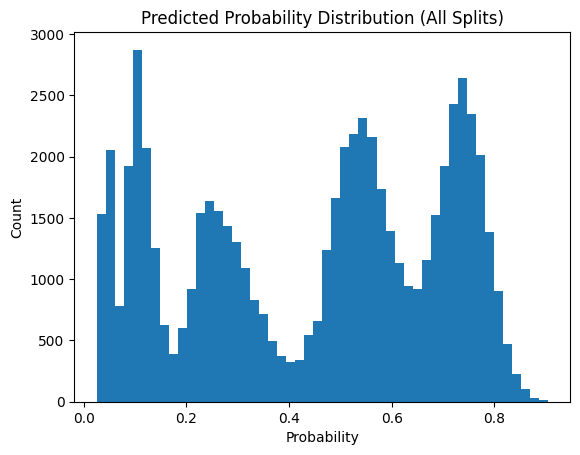

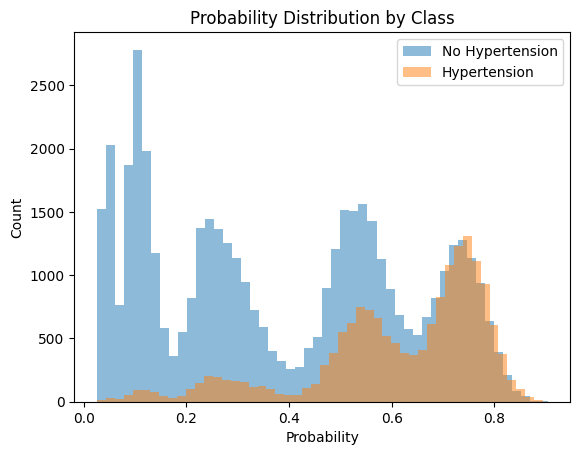

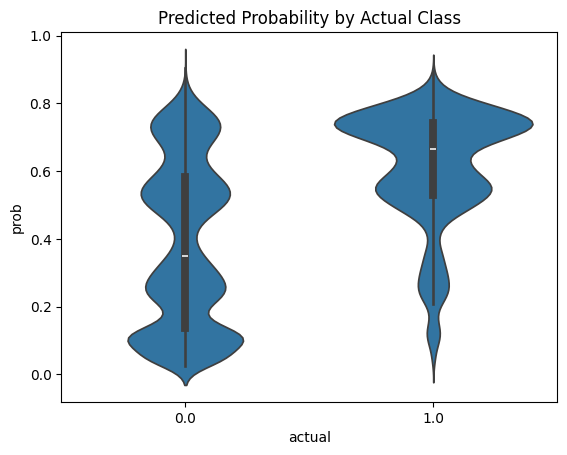

In [26]:
## evaluating predictions distributions and probabilitiies for a risk grouping for the predictive function/tool/ui.
y_train_proba = best_pipe.predict_proba(X_train)[:, 1]
y_val_proba   = best_pipe.predict_proba(X_val)[:, 1]
y_test_proba  = best_pipe.predict_proba(X_test)[:, 1]


df_probs = pd.DataFrame({
    "prob": list(y_train_proba) + list(y_val_proba) + list(y_test_proba),
    "actual": list(y_train) + list(y_val) + list(y_test),
    "split": (["train"] * len(y_train_proba) +
              ["val"]   * len(y_val_proba) +
              ["test"]  * len(y_test_proba))
})

import matplotlib.pyplot as plt

plt.hist(df_probs["prob"], bins=50)
plt.title("Predicted Probability Distribution (All Splits)")
plt.xlabel("Probability")
plt.ylabel("Count")
plt.show()

plt.hist(df_probs[df_probs["actual"] == 0]["prob"], bins=50, alpha=0.5, label="No Hypertension")
plt.hist(df_probs[df_probs["actual"] == 1]["prob"], bins=50, alpha=0.5, label="Hypertension")

plt.legend()
plt.title("Probability Distribution by Class")
plt.xlabel("Probability")
plt.ylabel("Count")
plt.show()

sns.violinplot(x="actual", y="prob", data=df_probs)
plt.title("Predicted Probability by Actual Class")
plt.show()

## Model Performance and Risk Classification

The model achieves moderate overall performance, with:
- **Accuracy (~69%)**: The model correctly predicts hypertension status about 7 out of 10 times overall.
- **Precision (~46% for hypertension)**: When the model predicts hypertension, it is correct less than half the time. This reflects some **false positives**.
- **Recall (~76% for hypertension)**: The model successfully identifies most individuals who actually have hypertension.

### Interpretation

The model is **better at identifying people with hypertension (high recall)** than it is at avoiding false positives (lower precision). This is acceptable for a health risk screening context, where missing a true case (false negative) is more concerning than flagging (false positive) someone as at risk.
However, the model does not perfectly separate the two groups. There is a clear **overlap in predicted probabilities**, meaning some individuals fall into an uncertain middle range.

### Why Use Risk Categories Instead of Raw Probabilities

Because of this overlap:
- A single probability value can be difficult to interpret reliably.
- Small differences in probability (e.g., 0.58 vs 0.62) may not meaningfully change risk.


In [27]:


model_features = feats
from IPython.display import display, Markdown

def collect_user_answers(feature_list=model_features, dictionary=anal_dict):
    answers = {}
    
    for feature in feature_list:
        details = get_recode_vdtls(feature, dictionary=dictionary)
        
        if details is None:
            print(f"No details found for {feature}, skipping.")
            continue
        
        print("\n" + "="*70)
        print(f"Question for: {feature}")
        print("Concept:", details["concept"])
        
        if details["universe"]:
            print("Universe:", details["universe"])
        
        print("\nValid responses:")
        for code, label in details["label_map"].items():
            print(f"  {code} = {label}")
        
        # force notebook to render output before input
        display(Markdown("---"))
        while True:
            
            response = input(f"Enter code for {feature} (q to quit): ")
                
            if response.lower() == "q":
                print("\nQuestionnaire cancelled.")
                return None  # exit entire function
            try:
                response = int(response)
                if response in details["label_map"]:
                    answers[feature] = response
                    break
                else:
                    print("Invalid code. Please choose one of the listed codes.")
            except ValueError:
                print("Please enter an integer code.")
    
    return answers



def hBPclassifier(answers, model=best_pipe, dictionary=anal_dict):
    model_features = feats
    """[
        'smoking_status', 'alcohol_frequency', 'bmi_risk', 'age_group',
        'sex', 'income', 'education', 'household_size', 'region',
        'immigrant_status', 'food_security'
    ]"""
    
    missing_features = [f for f in model_features if f not in answers]
    if missing_features:
        raise ValueError(f"Missing answers for: {missing_features}")
    
    for feature in model_features:
        details = get_recode_vdtls(feature, dictionary=dictionary)
        valid_codes = list(details["label_map"].keys())
        
        if answers[feature] not in valid_codes:
            raise ValueError(
                f"Invalid code for {feature}: {answers[feature]}. "
                f"Valid codes: {valid_codes}"
            )
    
    user_df = pd.DataFrame([answers])[model_features]
    prob = model.predict_proba(user_df)[0, 1]
    
    return prob


user_answers = collect_user_answers()
if user_answers is not None:
    hBP = hBPclassifier(user_answers)
    print("\nPredicted probability of high blood pressure:", round(hBP, 4))
    print("Percent:", round(hBP * 100, 2), "%")


Question for: smoking_status
Concept: Smokingstatus(type2)-traditionaldefinition-(D)
Universe: Respondentsaged18andolder

Valid responses:
  0 = Non-smoker
  1 = Former smoker
  2 = Current smoker


---


Questionnaire cancelled.


# user interface script was created using this model and classifying risk groups low/mod/high. below is hold out from saving the model and variables, labels, etc for the ui tool.

In [28]:
"""# save model for future interface - .py files supplement to notebook

%pip install streamlit
#import joblib

#joblib.dump(best_pipe, "BPmodel.joblib")
#feats
#print(X.columns.tolist())""""CST2101_HypertensionDataDiveV2 copy.ipynb"

'# save model for future interface - .py files supplement to notebook\n\n%pip install streamlit\n#import joblib\n\n#joblib.dump(best_pipe, "BPmodel.joblib")\n#feats\n#print(X.columns.tolist())CST2101_HypertensionDataDiveV2 copy.ipynb'